**STEP 1: Imports and Reading Data**

In [278]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
#import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
#plt.style.use('ggplot')
#pd.set_option('max_columns',200) # Setting the columns to 200 so that we can see them all

In [279]:
df=pd.read_csv(r"D:\IIT_MADRAS\CAPSTONE_PROJECT\FINAL_WALMART_PROJECT\Walmart DataSet.csv")

**STEP2: Data Understanding**  
* Dataframe shape  
* head and tail
* Columns list  
* dtypes  
* describe     


In [280]:
df.shape

(6435, 8)

In [281]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [282]:
list(df.columns)

['Store',
 'Date',
 'Weekly_Sales',
 'Holiday_Flag',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment']

In [283]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [284]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


**STEP 3: Data Preparation**  
* Changing the column datatype of object type to date
* Creating new columns or Renaming columns if any.
* Dropping irrelevant columns and rows  
* Identifying duplicated columns  
* Setting the index to Date column
  


In [285]:
#Keeping dayfirst=True since the date format is in dd-mm-yyyy
df['Date']=pd.to_datetime(df['Date'],dayfirst=True) #Forcing the "Date" column to datetime instead of an object. 
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [286]:
df["Month"]=df["Date"].dt.month
df["Year"]=df["Date"].dt.year
df.head(20)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,3,2010
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,3,2010
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,3,2010
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,4,2010
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808,4,2010


In [287]:
#Example of dropping column using drop command
#df.drop(["CPI"],axis=1,inplace=True)

#Example of dropping columns using subsetting
#df[['Store', #'Date', 
#    'Weekly_Sales', 'Holiday_Flag', 'Temperature',
#       'Fuel_Price', 'Unemployment']]

In [288]:
df.isna().sum() # checking for the null values in the dataset. If found we either drop or replace them.

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Month           0
Year            0
dtype: int64

In [289]:
df.loc[df.duplicated()]# Duplicated rows give where two rows are exactly the same. Duplicated by default will give the all the additional rows and ignore the first one.

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year


In [290]:
df.duplicated().sum()

0

In [291]:
df.set_index(df["Date"],inplace=True)
df.drop("Date",axis=1,inplace=True) #Droppping the date  column
df.head(20)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010
2010-03-12,1,1439541.59,0,57.79,2.667,211.380643,8.106,3,2010
2010-03-19,1,1472515.79,0,54.58,2.720,211.215635,8.106,3,2010
2010-03-26,1,1404429.92,0,51.45,2.732,211.018042,8.106,3,2010
2010-04-02,1,1594968.28,0,62.27,2.719,210.820450,7.808,4,2010


**STEP 3: Feature Understanding**    
* Plotting Feature Distributions
    * Histogram  
    * KDE
    * Boxplot

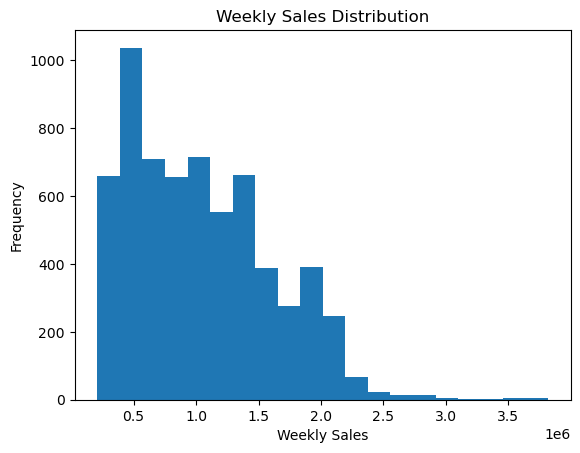

In [292]:
ax=df["Weekly_Sales"].plot(kind="hist",bins=20,title="Weekly Sales Distribution")
ax.set_xlabel("Weekly Sales")
plt.show()

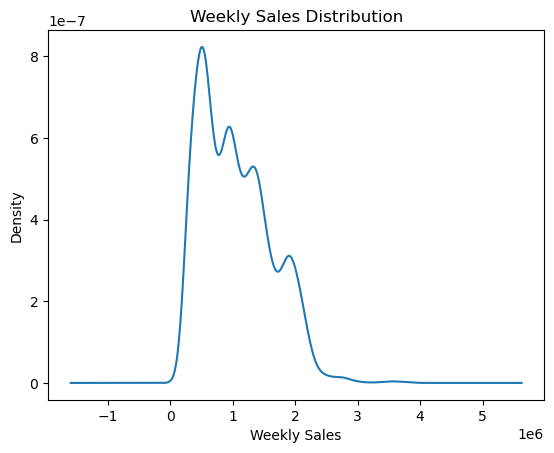

In [293]:
ax=df["Weekly_Sales"].plot(kind="kde",title="Weekly Sales Distribution")
ax.set_xlabel("Weekly Sales")
plt.show()

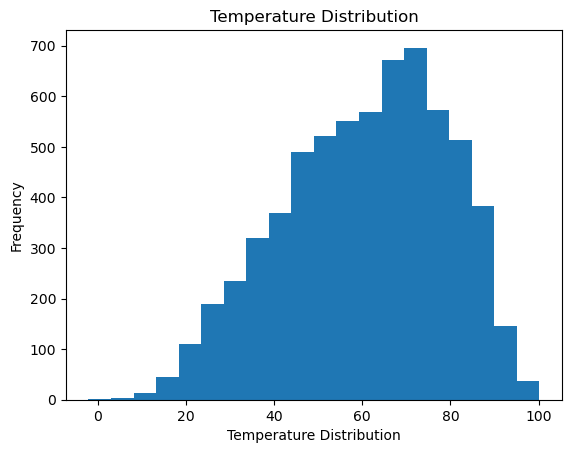

In [294]:
ax=df["Temperature"].plot(kind="hist",bins=20,title="Temperature Distribution")
ax.set_xlabel("Temperature Distribution")
plt.show()

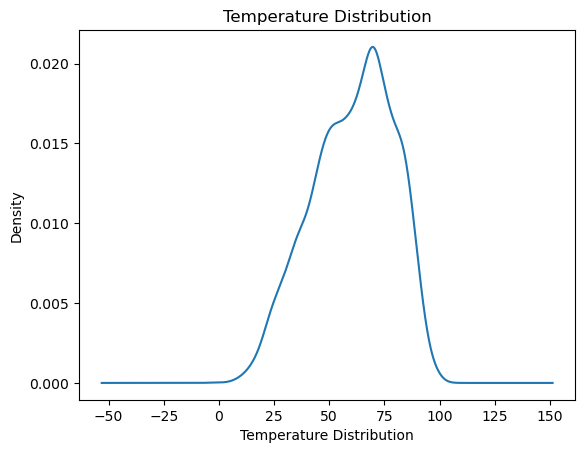

In [295]:
ax=df["Temperature"].plot(kind="kde",title="Temperature Distribution")
ax.set_xlabel("Temperature Distribution")
plt.show()

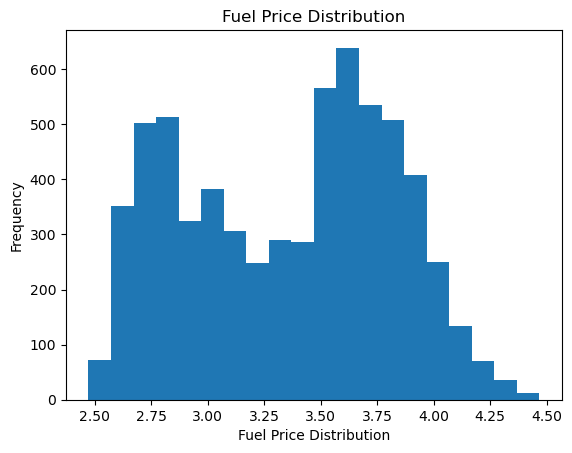

In [296]:
ax=df["Fuel_Price"].plot(kind="hist",bins=20,title="Fuel Price Distribution")
ax.set_xlabel("Fuel Price Distribution")
plt.show()

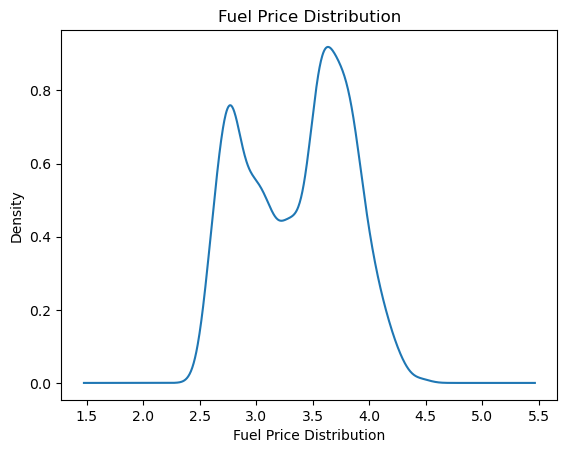

In [297]:
ax=df["Fuel_Price"].plot(kind="kde",title="Fuel Price Distribution")
ax.set_xlabel("Fuel Price Distribution")
plt.show()

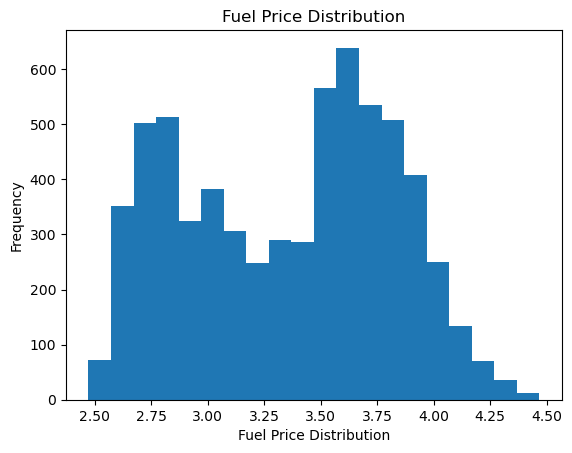

In [298]:
ax=df["Fuel_Price"].plot(kind="hist",bins=20,title="Fuel Price Distribution")
ax.set_xlabel("Fuel Price Distribution")
plt.show()

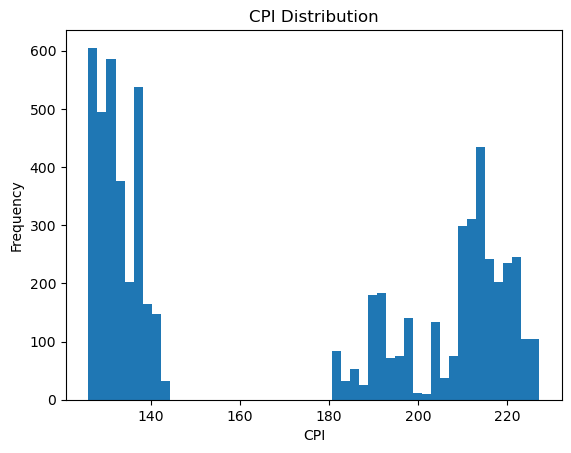

In [299]:
ax=df["CPI"].plot(kind="hist",bins=50,title="CPI Distribution")
ax.set_xlabel("CPI")
plt.show()

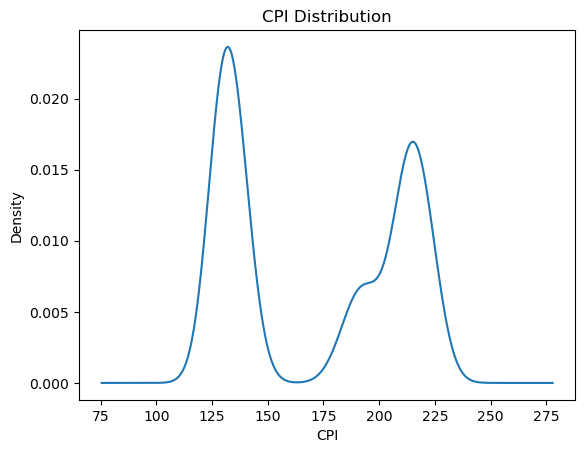

In [300]:
ax=df["CPI"].plot(kind="kde",title="CPI Distribution")
ax.set_xlabel("CPI")
plt.show()

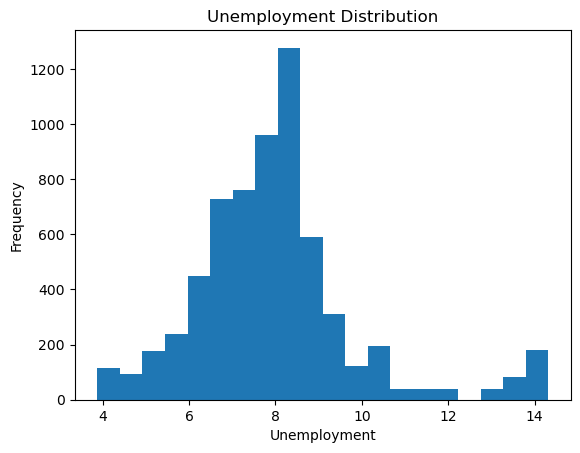

In [301]:
ax=df["Unemployment"].plot(kind="hist",bins=20,title="Unemployment Distribution")
ax.set_xlabel("Unemployment")
plt.show()

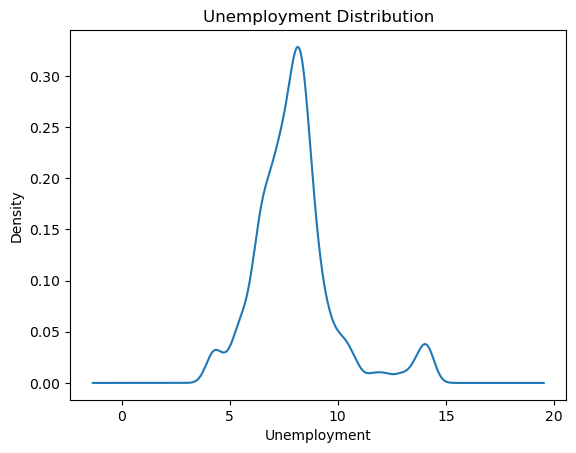

In [302]:
ax=df["Unemployment"].plot(kind="kde",title="Unemployment Distribution")
ax.set_xlabel("Unemployment")
plt.show()

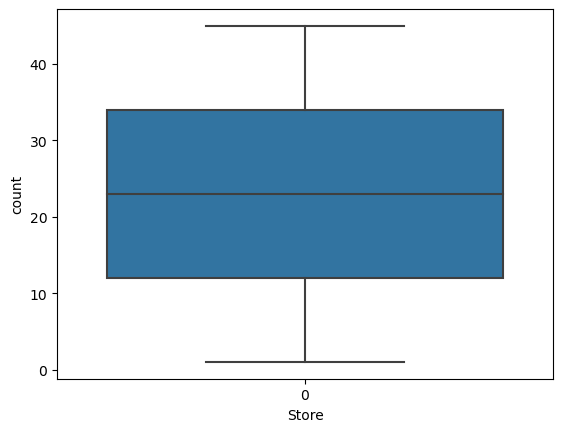

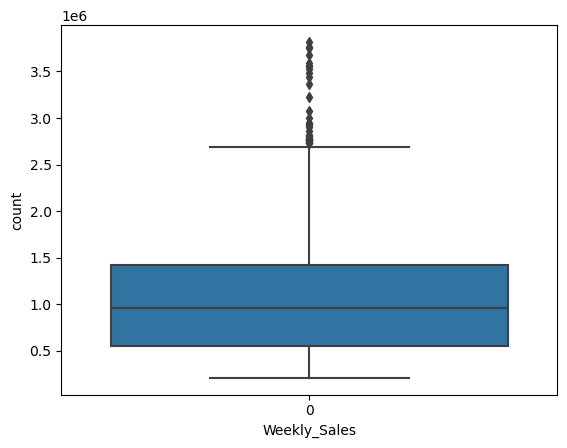

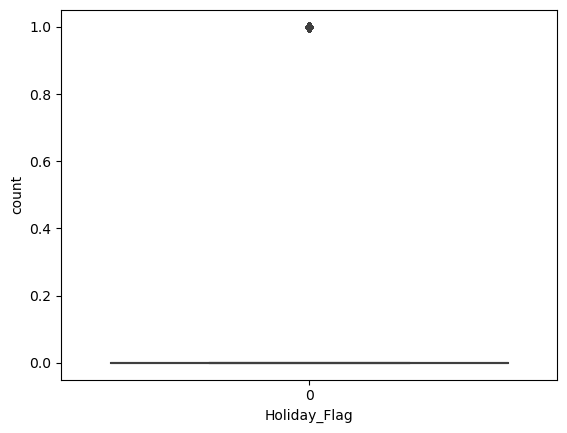

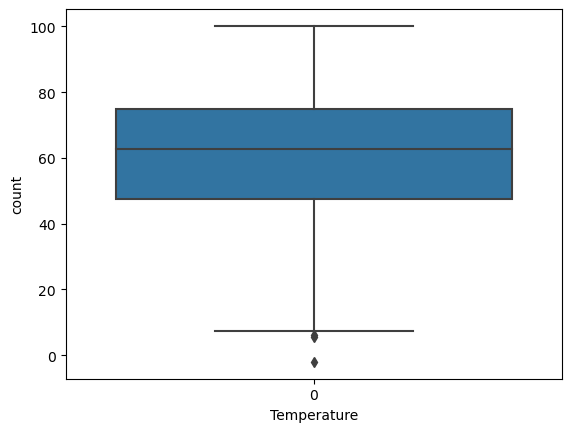

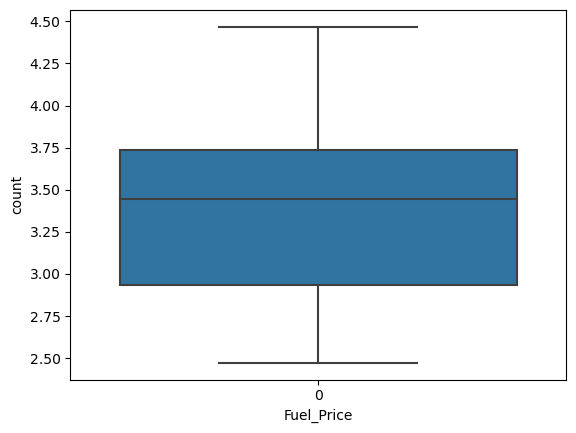

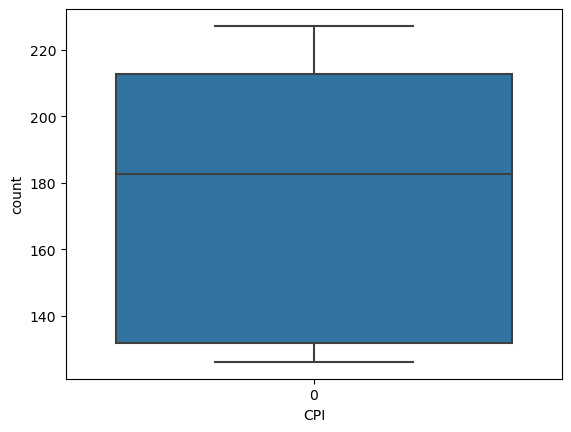

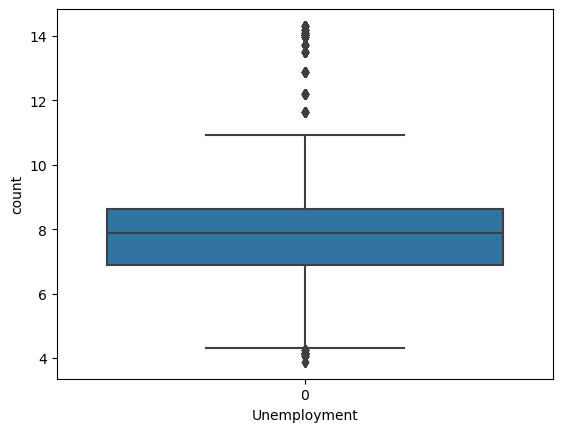

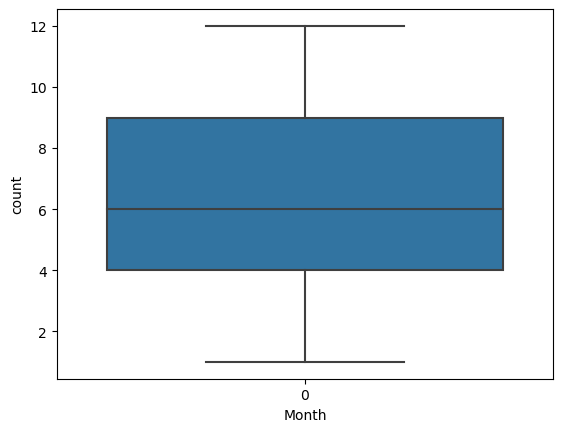

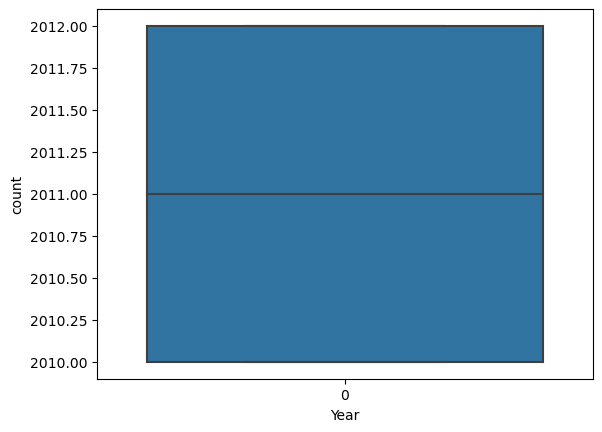

In [303]:
cols=list(df.columns)
for col_name in cols:
    if((df[col_name].dtypes=="int64") | (df[col_name].dtypes=="float64")):
        sns.boxplot(df[col_name])
        plt.xlabel(col_name)
        plt.ylabel("count")
        plt.show()
                  
        

**STEP 4 : Feature Relationship**  
* Scatterplot 
* Pairplot
* Heatmap Correlation




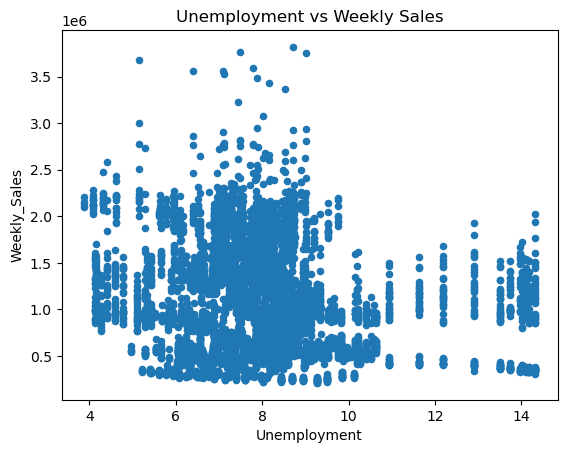

In [304]:
#Scatter plots are used to compare two features
df.plot(kind="scatter",x="Unemployment",y="Weekly_Sales",title="Unemployment vs Weekly Sales")
plt.show()

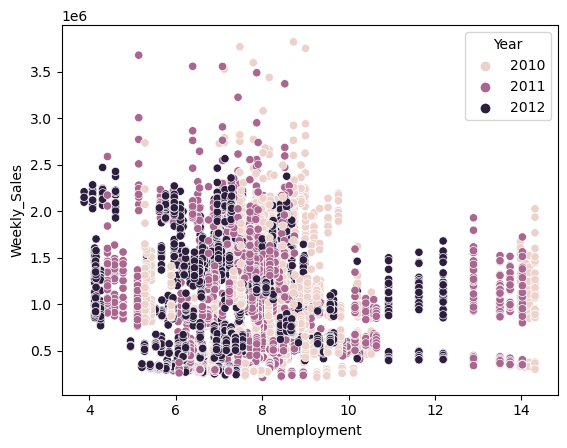

In [305]:
sns.scatterplot(data=df,x="Unemployment",y="Weekly_Sales",hue="Year")
plt.show()

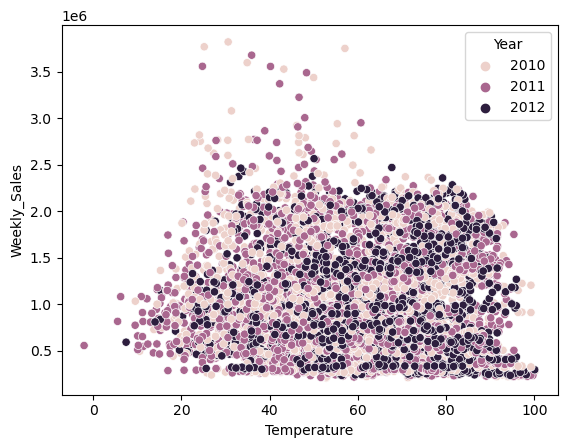

In [306]:
sns.scatterplot(data=df,x="Temperature",y="Weekly_Sales", hue="Year")
plt.show()

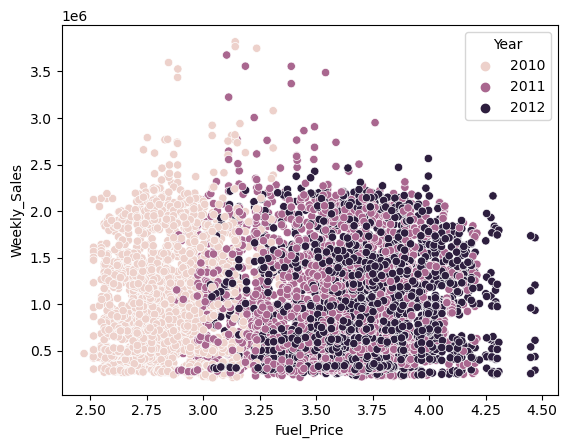

In [307]:
sns.scatterplot(data=df,x="Fuel_Price",y="Weekly_Sales",hue="Year")
plt.show()

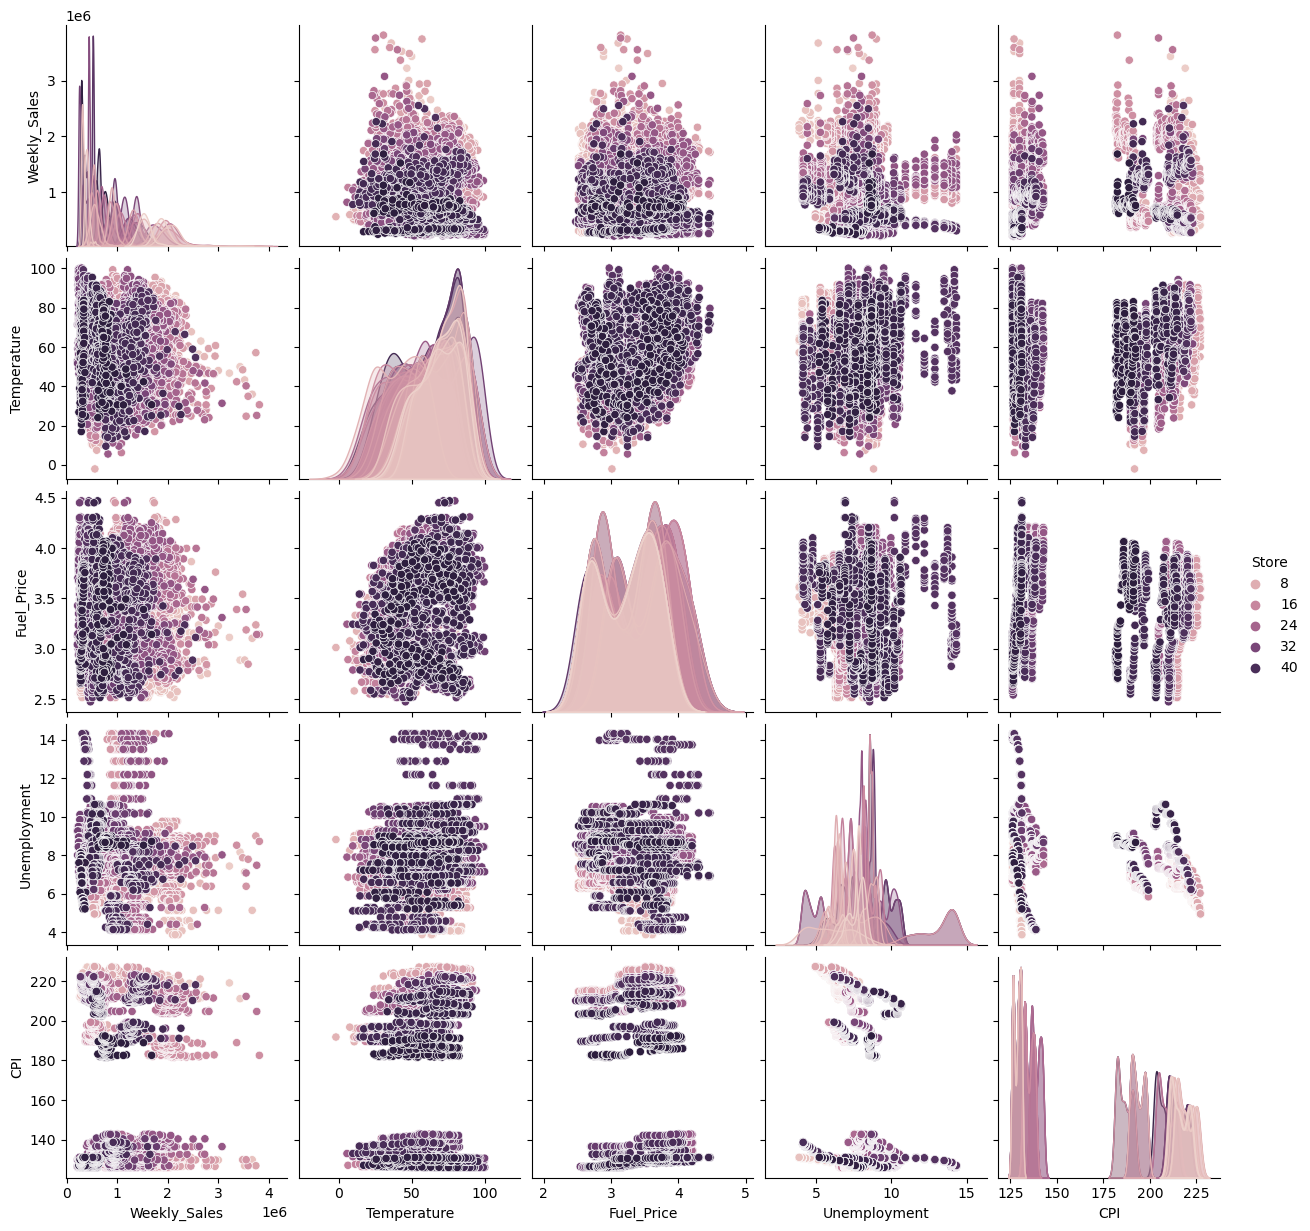

In [308]:
#Now if we want compare more than 2 features we use pair plots.It displays in matrix form
sns.pairplot(df,vars=["Weekly_Sales","Temperature","Fuel_Price","Unemployment","CPI"],hue="Store")
plt.show()

In [309]:
#Checking correlation on a subset of columns in the dataset.
df_corr=df[["Weekly_Sales","Temperature","Fuel_Price","Unemployment","CPI"]].corr()
df_corr

,Weekly_Sales,Temperature,Fuel_Price,Unemployment,CPI
Weekly_Sales,1.000000,-0.063810,0.009464,-0.106176,-0.072634
Temperature,-0.063810,1.000000,0.144982,0.101158,0.176888
Fuel_Price,0.009464,0.144982,1.000000,-0.034684,-0.170642
Unemployment,-0.106176,0.101158,-0.034684,1.000000,-0.302020
CPI,-0.072634,0.176888,-0.170642,-0.302020,1.000000


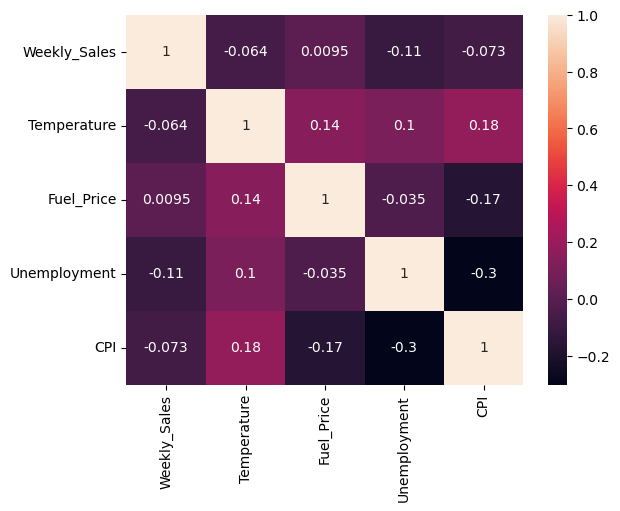

In [310]:
#Another way to look at correlation using seaborn heatmap
sns.heatmap(df_corr,annot=True)
plt.show()

**STEP 5 : Ask a question about the data**  
* Try to answer a question you have about the data using a plot or statistic

**a. If the weekly sales are affected by the unemployment rate, if yes - which stores
are suffering the most?**

**Answer :** Yes, the weekly sales and the unemployment rate are inversely proportional.From the pair plots and the heat map mentioned above we can see that when the Unemployment is less than 9% ,weekly sales are approximately to the maximum. As the unemployment rate moves above 9%, weekly sales start dropping.

In [311]:
df.groupby("Store")[["Unemployment","Weekly_Sales"]].agg({"Unemployment":'mean',"Weekly_Sales":'sum'}).sort_values(by=['Unemployment'],ascending=False)

,Unemployment,Weekly_Sales
Store,,
28,13.116483,1.892637e+08
38,13.116483,5.515963e+07
12,13.116483,1.442872e+08
43,9.934804,9.056544e+07
34,9.934804,1.382498e+08
29,9.806385,7.714155e+07
18,8.838301,1.551147e+08
35,8.788573,1.315207e+08
14,8.648748,2.889999e+08


**From the above data and the pair plots we can infer that stores: 28,28 and 12 are the top 3 stores which are suffering the most with Unemployment rate 13%**

**b. If the weekly sales show a seasonal trend, when and what could be the reason?**

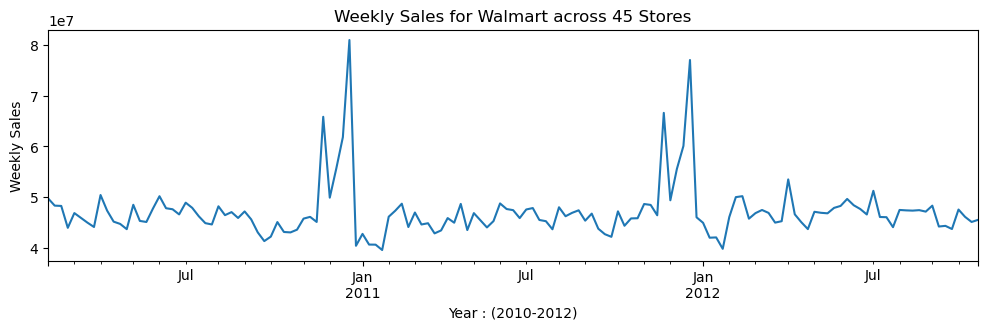

In [312]:
ax=df.groupby(df.index)["Weekly_Sales"].sum().plot(kind="line",title="Weekly Sales for Walmart across 45 Stores",figsize=(12,3))
ax.set_xlabel("Year : (2010-2012)")
ax.set_ylabel("Weekly Sales")
plt.show()

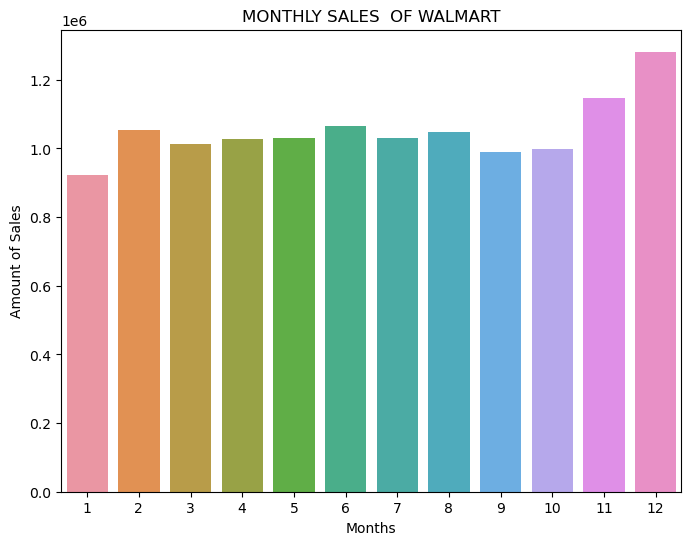

In [313]:
#Getting the mean monthly sales for walmart between Feb-2010 and Oct-2012
monthly_sales=df.groupby("Month")[["Weekly_Sales"]].mean().round(2)
plt.figure(figsize=(8,6))
sns.barplot(data=monthly_sales, x=monthly_sales.index,y=monthly_sales["Weekly_Sales"])
plt.xlabel("Months")
plt.ylabel("Amount of Sales")
plt.title("MONTHLY SALES  OF WALMART")
plt.show()

From the above plot we can infer that weekly sales show a seasonal trend(Exhibiting repeating patterns every year). Every year they peak in December. Since December is a holiday season and with xmas and New year sales are expected to spike.

**c. Does temperature affect the weekly sales in any manner?**

From the correlation data and the pair plots mentioned above we can infer that temperature and weekly_sales are neagatively correlated. The ideal temperature is between 20-60 for a good sale.

**d. How is the Consumer Price index affecting the weekly sales of various stores?**

From the correlation data and the pair plots mentioned above we can infer that not much of correlation between CPI and the weekly sales.

**e. Top performing stores according to the historical data.**

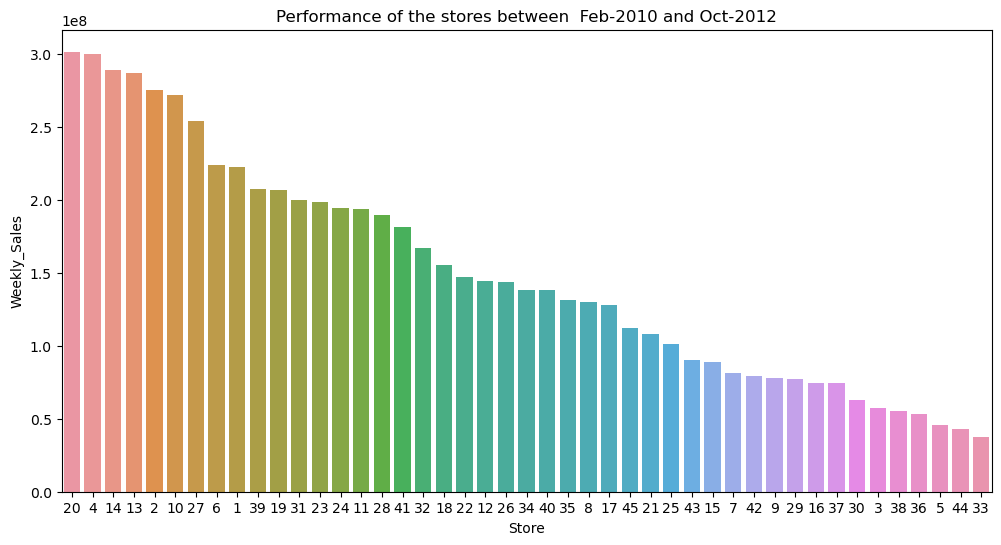

In [314]:
#Making the barplot and sorting the bars
plt.figure(figsize=(12,6))
store_sales=df.groupby("Store")[["Weekly_Sales"]].sum().sort_values(by=["Weekly_Sales"],ascending=False)
sns.barplot(data= store_sales,x=store_sales.index,y=store_sales.Weekly_Sales,order=store_sales.sort_values(by="Weekly_Sales",ascending=False).index)
plt.title("Performance of the stores between  Feb-2010 and Oct-2012")
plt.show()

According to the bar plot mentioned above we can infer the Top 3 performing stores as per the Weekly Sales  
* Store 20  
* Store 4
* Store 14

**f. The worst performing store, and how significant is the difference between the
highest and lowest performing stores.**

According to the bar plot mentioned above we can infer that the worst performing store as per the weekly sales is store : 33. There is 14%significant difference between the top and the worst performing store.

In [315]:
a=df[df["Store"]==20]["Weekly_Sales"].sum()

In [316]:
b=df[df["Store"]==33]["Weekly_Sales"].sum()

In [317]:
(b/(a-b))*100

14.063186355249957

**PREDECTIVE MODELLING FOR THE TOP PERFORMING STORE :20**

**Installation of prophet (Name changed from fbprophet to Prophet)**

**!pip install Prophet**

In [318]:
from prophet import Prophet


In [319]:
model=Prophet() #creating an object of the model.

In [320]:
df_20=df[df["Store"]==20]
df_20.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,20,2401395.47,0,25.92,2.784,204.247194,8.187,2,2010
2010-02-12,20,2109107.90,1,22.12,2.773,204.385747,8.187,2,2010
2010-02-19,20,2161549.76,0,25.43,2.745,204.432100,8.187,2,2010
2010-02-26,20,1898193.95,0,32.32,2.754,204.463087,8.187,2,2010
2010-03-05,20,2119213.72,0,31.75,2.777,204.494073,8.187,3,2010


In [321]:
df_20["ds"]=df_20.index

In [322]:
df_20.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [323]:
df_20.reset_index(drop=True,inplace=True)#Dropping the indexed column


In [324]:
df_20=df_20[["ds","Weekly_Sales"]].rename(columns={"Weekly_Sales":"y"})

In [325]:
df_20.head()

,ds,y
0,2010-02-05,2401395.47
1,2010-02-12,2109107.90
2,2010-02-19,2161549.76
3,2010-02-26,1898193.95
4,2010-03-05,2119213.72


In [326]:
#Fitting the model
model.fit(df_20)

23:09:45 - cmdstanpy - INFO - Chain [1] start processing
23:09:45 - cmdstanpy - INFO - Chain [1] done processing


In [327]:
# Periods is given in months here(12 weeks = 3months) ,MS stands for Month Start
future_dates=model.make_future_dataframe(periods=12,freq="W-FRI") #The week day it should run is friday

In [328]:
future_dates.tail(20)

,ds
135,2012-09-07
136,2012-09-14
137,2012-09-21
138,2012-09-28
139,2012-10-05
140,2012-10-12
141,2012-10-19
142,2012-10-26
143,2012-11-02
144,2012-11-09


In [329]:
#Maing predictions for the futire dates
forecast=model.predict(future_dates)

In [330]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
150,2012-12-21,3.023629e+06,2.789211e+06,3.258826e+06
151,2012-12-28,2.690491e+06,2.456611e+06,2.915311e+06
152,2013-01-04,2.172592e+06,1.950095e+06,2.389717e+06
153,2013-01-11,1.786691e+06,1.562585e+06,2.021762e+06
154,2013-01-18,1.744309e+06,1.516469e+06,1.974066e+06


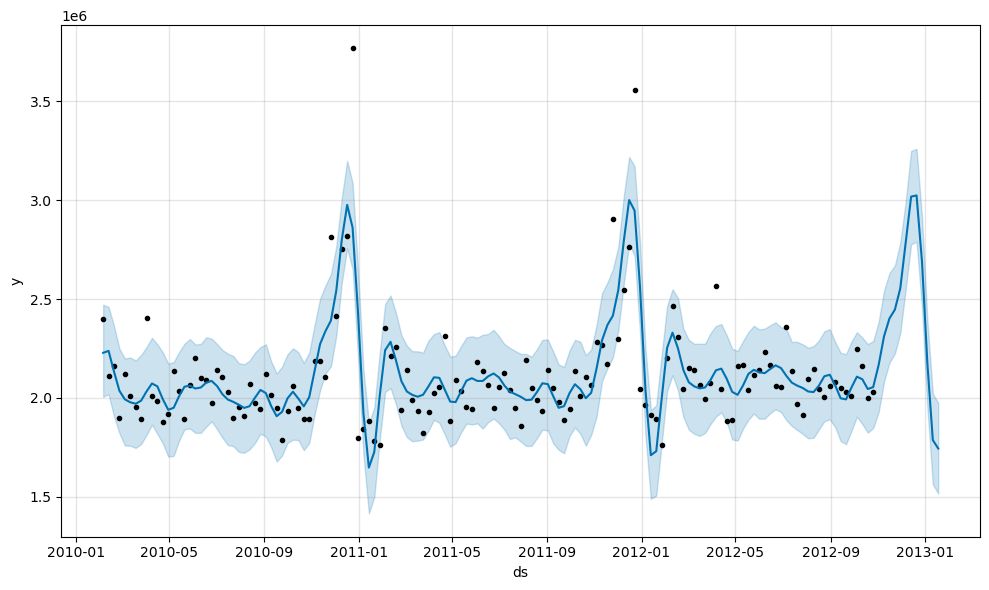

In [331]:
fig1=model.plot(forecast) #Assigning it to fig 1 otherwise 2 graphs are coming

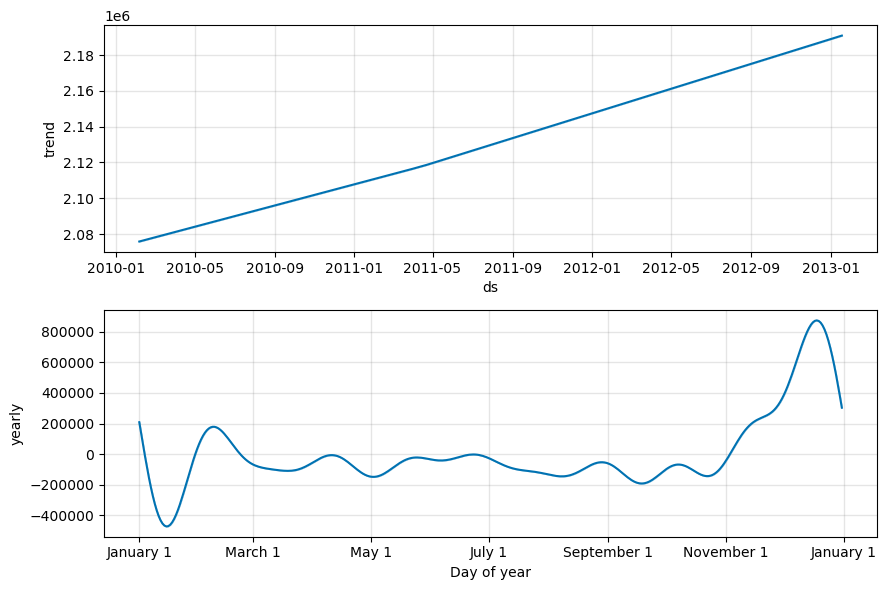

In [332]:
#f you want to see the forecast components, you can use the Prophet.plot_components method. 
#Visualize the components [Trends,yearly]
fig2=model.plot_components(forecast)

In [333]:
from prophet.diagnostics import cross_validation
df_20_cv = cross_validation(model,initial="730 days", period= "45 days", horizon="90 days")

  0%|          | 0/4 [00:00<?, ?it/s]

23:09:48 - cmdstanpy - INFO - Chain [1] start processing
23:09:48 - cmdstanpy - INFO - Chain [1] done processing
23:09:48 - cmdstanpy - INFO - Chain [1] start processing
23:09:48 - cmdstanpy - INFO - Chain [1] done processing
23:09:49 - cmdstanpy - INFO - Chain [1] start processing
23:09:49 - cmdstanpy - INFO - Chain [1] done processing
23:09:49 - cmdstanpy - INFO - Chain [1] start processing
23:09:49 - cmdstanpy - INFO - Chain [1] done processing


In [334]:
from prophet.diagnostics import performance_metrics
df_20_p=performance_metrics(df_20_cv)
df_20_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,8 days,9.661866e+09,98294.791778,66872.093510,0.031420,0.015362,0.032508,1.0
1,9 days,1.179626e+10,108610.581149,82140.728246,0.038836,0.048186,0.039633,1.0
2,12 days,1.572135e+10,125384.821157,109914.914295,0.051646,0.052444,0.052875,1.0
3,13 days,1.260724e+10,112281.958133,100730.105401,0.047523,0.052444,0.048406,1.0
4,15 days,1.133512e+10,106466.509960,92915.002206,0.043848,0.052444,0.044584,1.0
5,16 days,1.229537e+10,110884.495508,105265.593316,0.049830,0.052444,0.050455,1.0
6,19 days,1.055283e+10,102726.954004,94543.795663,0.044682,0.033927,0.045504,1.0
7,20 days,6.644316e+09,81512.675672,68362.171198,0.032658,0.029812,0.033046,1.0
8,22 days,5.043591e+10,224579.417645,137118.629291,0.057217,0.029812,0.061161,0.8
9,23 days,6.592824e+10,256764.957308,181770.272777,0.075436,0.033927,0.080847,0.6


**SARIMAX MODEL**

In [335]:
df_20=df
df_20.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [336]:
df_20=df[df["Store"]==20]
df_20.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,20,2401395.47,0,25.92,2.784,204.247194,8.187,2,2010
2010-02-12,20,2109107.90,1,22.12,2.773,204.385747,8.187,2,2010
2010-02-19,20,2161549.76,0,25.43,2.745,204.432100,8.187,2,2010
2010-02-26,20,1898193.95,0,32.32,2.754,204.463087,8.187,2,2010
2010-03-05,20,2119213.72,0,31.75,2.777,204.494073,8.187,3,2010


In [337]:
df_20.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [338]:
df_20.head()

,Weekly_Sales
Date,
2010-02-05,2401395.47
2010-02-12,2109107.90
2010-02-19,2161549.76
2010-02-26,1898193.95
2010-03-05,2119213.72


In [339]:
df_20.isna().sum()

Weekly_Sales    0
dtype: int64

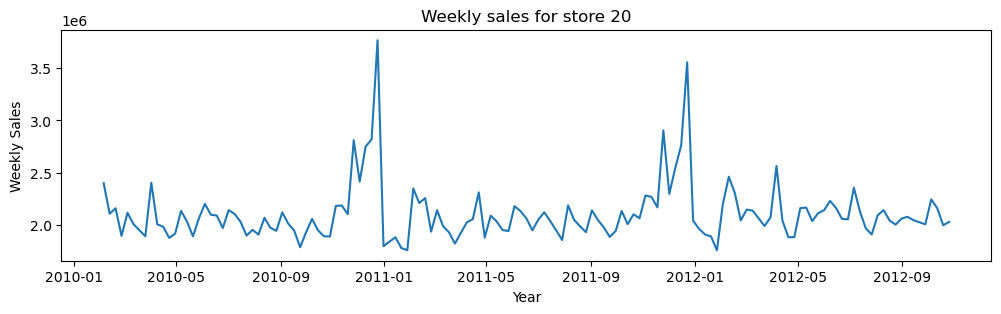

In [340]:
#PLOT THE WEKLY SALES FOR STORE : 20
plt.figure(figsize=(12,3))
plt.plot(df_20["Weekly_Sales"])
plt.xlabel("Year")
plt.ylabel("Weekly Sales")
plt.title(f"Weekly sales for store 20")
plt.show()

**Checking for stationarity in the data**

In [341]:

# Null Hypothesis: Data is not stationary
# Alternate Hypothesis:Data is stationary (This is the claim)
from statsmodels.tsa.stattools import adfuller
result=adfuller(df_20["Weekly_Sales"])
print(f'ADF Statistic:,{result[0]}') #some default value based upon the critial values
print(f'p-value:{result[1]}')

if(result[1]>0.05):
    print("The Data is Not Stationary")
else:
    print("The Data is Stationary")

ADF Statistic:,-5.393738692854832
p-value:3.4912952838128055e-06
The Data is Stationary


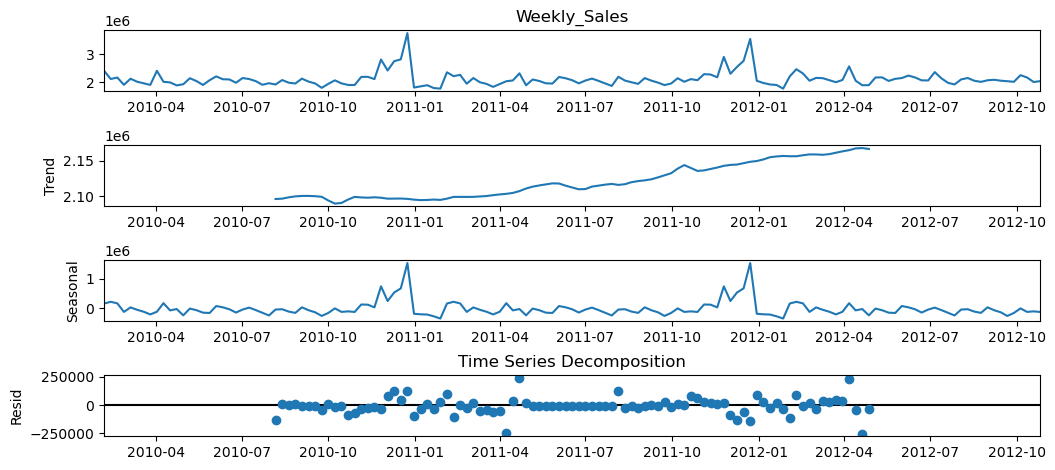

In [342]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df_20["Weekly_Sales"])
fig=decomposition.plot()
fig.set_figwidth(12)
plt.title("Time Series Decomposition")
plt.show()

**Building the model for Stationary data**

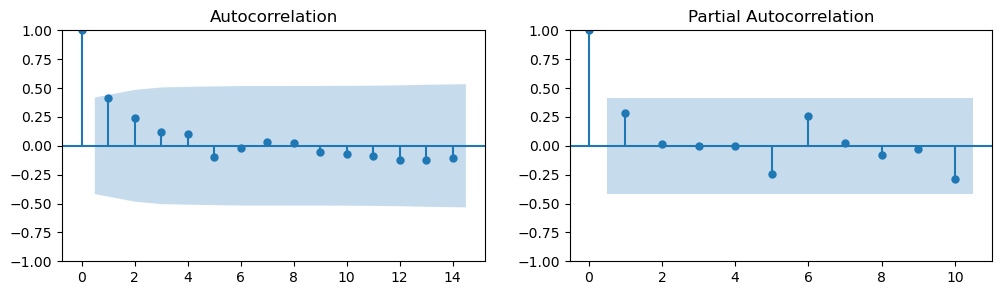

In [343]:
#Plotting the Autcorrelation plot and Partial Autocorrelation plot

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

fig,ax=plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(3)
acf_plot=acf(df_20["Weekly_Sales"])
plot_acf(acf_plot,ax=ax[0])

pacf_plot=pacf(df_20["Weekly_Sales"])
plot_pacf(pacf_plot,ax=ax[1],lags=10)
plt.show()

In [344]:
train=df_20.iloc[:115]["Weekly_Sales"]
test=df_20.iloc[115:]["Weekly_Sales"]

In [345]:
print("Training Data", train.shape)
print("Testing Data",test.shape)

Training Data (115,)
Testing Data (28,)


In [346]:
#Itertools
# How to find the ideal values for p,d,q:

import itertools
from statsmodels.tsa.arima.model import ARIMA
p = range(0,8)
q = range(0,8)
d = range(0,2)

pdq_combination = list(itertools.product(p,d,q))
pdq_combination


print(len(pdq_combination)) #total combinations of p,d,q

from sklearn.metrics import *
rmse = []
order1 = []
for pdq in pdq_combination:
    model = ARIMA(train,order=pdq)
    model_fit=model.fit()
    pred = model_fit.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
    error = np.sqrt(mean_squared_error(test, pred)) #Computing the mean_squarred error
    order1.append(pdq)
    rmse.append(error)
        
results = pd.DataFrame(index=order1, data=rmse, columns=['RMSE']) 
results.sort_values("RMSE",ascending=True) #Least RMSE score are best hyperparamterer for (p,d,q) values


128


,RMSE
"(1, 0, 3)",105142.034502
"(0, 0, 3)",105144.977148
"(0, 0, 1)",107444.097072
"(0, 0, 2)",108051.052042
"(2, 0, 3)",108184.698684
...,...
"(0, 1, 1)",144217.379912
"(6, 1, 2)",144600.076527
"(5, 1, 3)",144757.528662
"(5, 1, 1)",144928.003249


In [347]:
#Running the ARIMA model

model = ARIMA(train,order=(1,0,3)) #(p,d,q)
model=model.fit()

<Axes: xlabel='Date'>

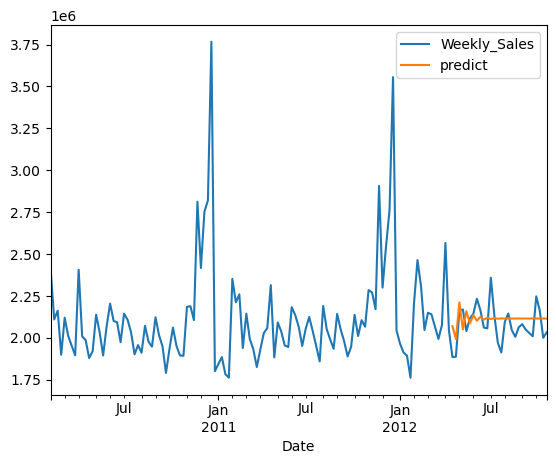

In [348]:
df_20['predict']=model.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
df_20[['Weekly_Sales','predict']].plot()

In [349]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [350]:
model=SARIMAX(train,order=(1,0,3),seasonal_order=(1,0,3,12))
model=model.fit()

<Axes: xlabel='Date'>

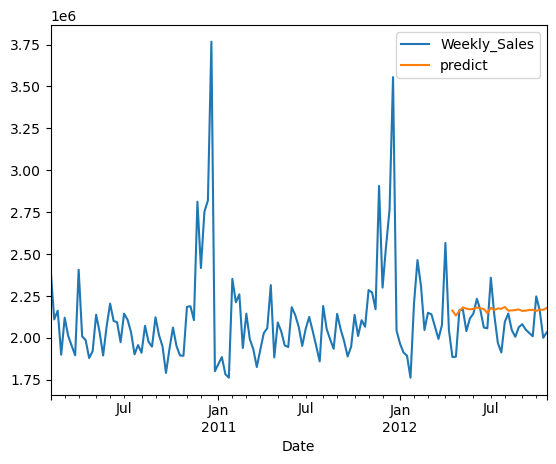

In [351]:
df_20['predict']=model.predict(start=len(train), end=len(train)+len(test)-1,dynamic=True)
df_20[['Weekly_Sales','predict']].plot()

<Axes: xlabel='Date'>

<Figure size 1200x300 with 0 Axes>

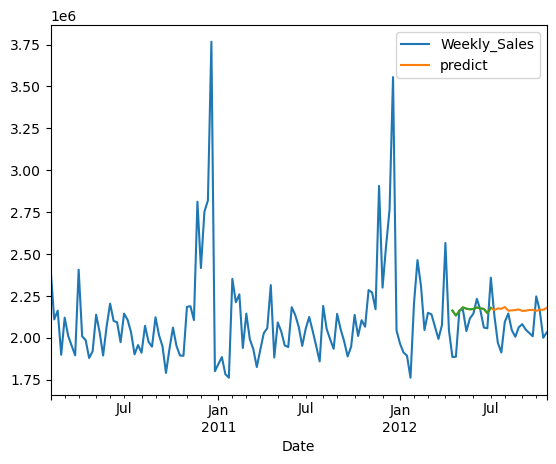

In [352]:
forecast = model.forecast(steps=12) #12 weeks
plt.figure(figsize=(12,3))
df_20.plot()
forecast.plot()

**Predictive modelling for STORE :4 ,Using Facebook Prophet**

In [353]:
from prophet import Prophet
model=Prophet()


In [354]:
df_4=df[df["Store"]==4]
df_4.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,4,2135143.87,0,43.76,2.598,126.442065,8.623,2,2010
2010-02-12,4,2188307.39,1,28.84,2.573,126.496258,8.623,2,2010
2010-02-19,4,2049860.26,0,36.45,2.540,126.526286,8.623,2,2010
2010-02-26,4,1925728.84,0,41.36,2.590,126.552286,8.623,2,2010
2010-03-05,4,1971057.44,0,43.49,2.654,126.578286,8.623,3,2010


In [355]:
df_4["ds"]=df_4.index

In [356]:
df_4.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)


In [357]:
df_4.reset_index(drop=True,inplace=True)#Dropping the indexed column

In [358]:
df_4=df_4[["ds","Weekly_Sales"]].rename(columns={"Weekly_Sales":"y"})

In [359]:
df_4.head()

,ds,y
0,2010-02-05,2135143.87
1,2010-02-12,2188307.39
2,2010-02-19,2049860.26
3,2010-02-26,1925728.84
4,2010-03-05,1971057.44


In [360]:
#Fitting the model
model.fit(df_4)

23:11:09 - cmdstanpy - INFO - Chain [1] start processing
23:11:09 - cmdstanpy - INFO - Chain [1] done processing


In [361]:
# Periods is given in months here(12 weeks = 3months) ,MS stands for Month Start
future_dates=model.make_future_dataframe(periods=12,freq="W-FRI") #The week day it should run is friday

In [362]:
future_dates.tail(20)

,ds
135,2012-09-07
136,2012-09-14
137,2012-09-21
138,2012-09-28
139,2012-10-05
140,2012-10-12
141,2012-10-19
142,2012-10-26
143,2012-11-02
144,2012-11-09


In [363]:
#Maing predictions for the futire dates
forecast=model.predict(future_dates)

In [364]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
150,2012-12-21,3.056358e+06,2.860857e+06,3.269510e+06
151,2012-12-28,2.805659e+06,2.594446e+06,3.006441e+06
152,2013-01-04,2.363786e+06,2.160253e+06,2.572265e+06
153,2013-01-11,2.004469e+06,1.805808e+06,2.205065e+06
154,2013-01-18,1.936045e+06,1.732039e+06,2.146997e+06


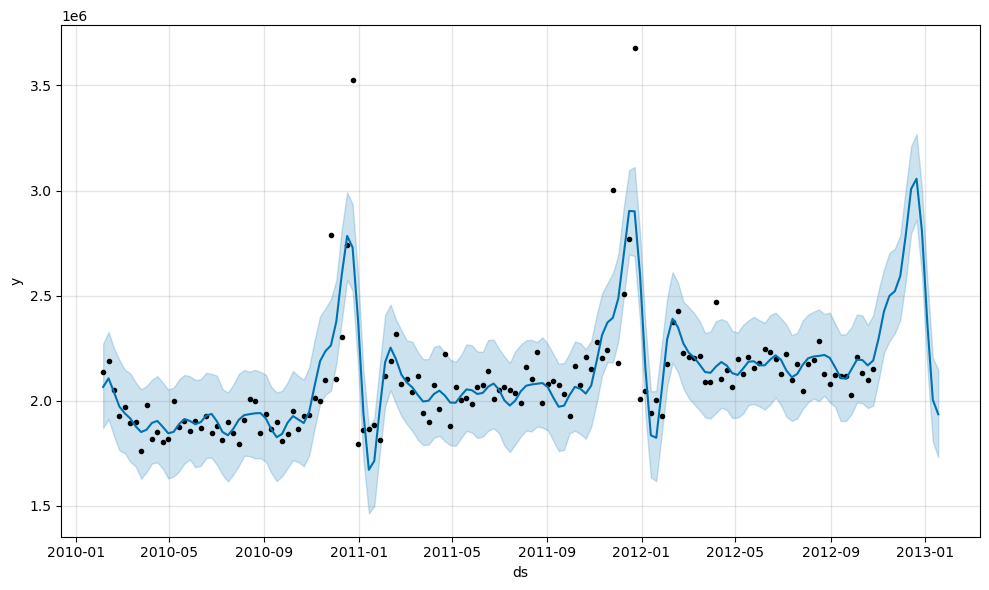

In [365]:
fig1=model.plot(forecast) #Assigning it to fig 1 otherwise 2 graphs are coming

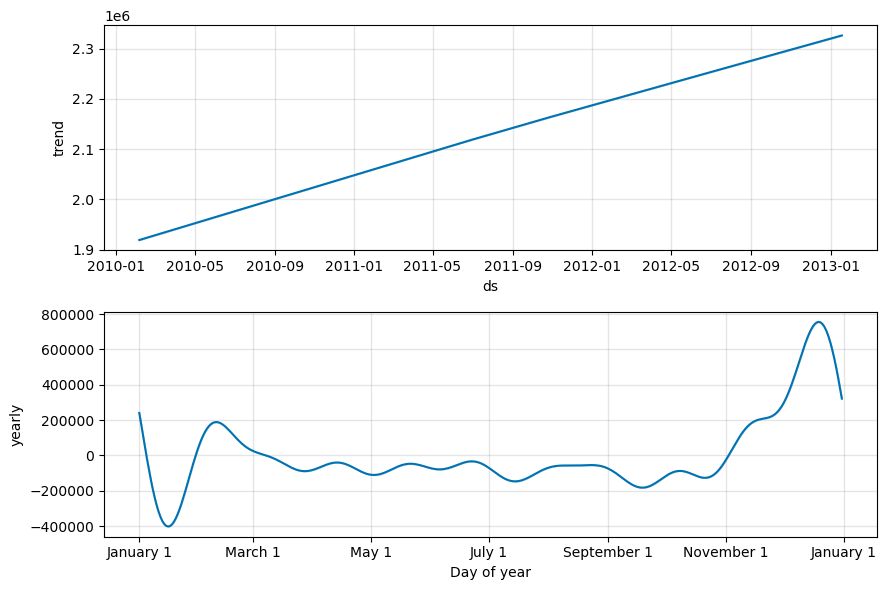

In [366]:
#f you want to see the forecast components, you can use the Prophet.plot_components method. 
#Visualize the components [Trends,yearly]
fig2=model.plot_components(forecast)

In [367]:
from prophet.diagnostics import cross_validation
df_4_cv = cross_validation(model,initial="730 days", period= "45 days", horizon="90 days")

  0%|          | 0/4 [00:00<?, ?it/s]

23:11:13 - cmdstanpy - INFO - Chain [1] start processing
23:11:13 - cmdstanpy - INFO - Chain [1] done processing
23:11:13 - cmdstanpy - INFO - Chain [1] start processing
23:11:13 - cmdstanpy - INFO - Chain [1] done processing
23:11:13 - cmdstanpy - INFO - Chain [1] start processing
23:11:14 - cmdstanpy - INFO - Chain [1] done processing
23:11:14 - cmdstanpy - INFO - Chain [1] start processing
23:11:14 - cmdstanpy - INFO - Chain [1] done processing


In [368]:
from prophet.diagnostics import performance_metrics
df_4_p=performance_metrics(df_4_cv)
df_4_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,8 days,1.748052e+09,41809.709148,37618.457159,0.017344,0.018178,0.017361,1.0
1,9 days,2.071138e+09,45509.758659,42131.395613,0.019415,0.021425,0.019375,1.0
2,12 days,2.505185e+09,50051.827672,49383.936290,0.022877,0.022586,0.022784,1.0
3,13 days,1.882740e+09,43390.554919,42938.877070,0.019948,0.021425,0.019746,1.0
4,15 days,1.767916e+09,42046.594359,41320.889447,0.019322,0.021425,0.019130,1.0
5,16 days,2.782936e+09,52753.538337,48913.878162,0.022810,0.021425,0.022511,1.0
6,19 days,2.346607e+09,48441.791992,40676.203446,0.019059,0.015047,0.018804,1.0
7,20 days,2.228888e+09,47211.104529,39361.446133,0.018175,0.015047,0.018004,1.0
8,22 days,2.258939e+10,150297.656773,97062.923532,0.041205,0.018165,0.042858,0.8
9,23 days,2.332628e+10,152729.421996,104446.830188,0.044341,0.030730,0.046113,0.8


**SARIMAX MODEL ON STORE :4**

In [369]:
df_4=df
df_4.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [370]:
df_4=df[df["Store"]==4]
df_4.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,4,2135143.87,0,43.76,2.598,126.442065,8.623,2,2010
2010-02-12,4,2188307.39,1,28.84,2.573,126.496258,8.623,2,2010
2010-02-19,4,2049860.26,0,36.45,2.540,126.526286,8.623,2,2010
2010-02-26,4,1925728.84,0,41.36,2.590,126.552286,8.623,2,2010
2010-03-05,4,1971057.44,0,43.49,2.654,126.578286,8.623,3,2010


In [371]:
df_4.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [372]:
df_4.head()

,Weekly_Sales
Date,
2010-02-05,2135143.87
2010-02-12,2188307.39
2010-02-19,2049860.26
2010-02-26,1925728.84
2010-03-05,1971057.44


In [373]:
df_4.isna().sum()

Weekly_Sales    0
dtype: int64

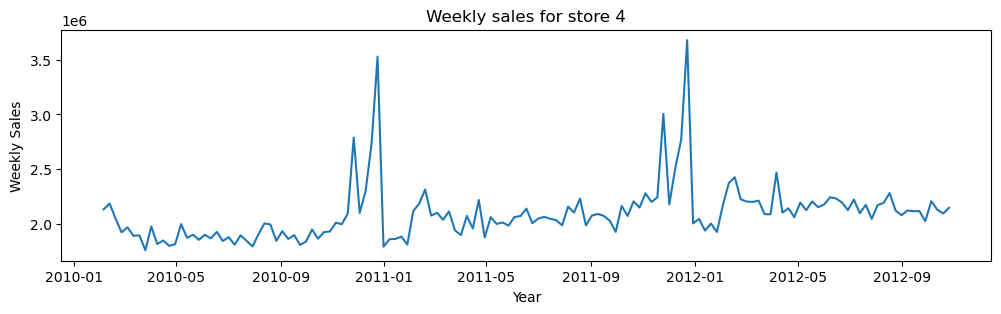

In [374]:
#PLOT THE WEKLY SALES FOR STORE : 4
plt.figure(figsize=(12,3))
plt.plot(df_4["Weekly_Sales"])
plt.xlabel("Year")
plt.ylabel("Weekly Sales")
plt.title(f"Weekly sales for store 4")
plt.show()

**Checking for stationarity in the data**

In [375]:
# Null Hypothesis: Data is not stationary
# Alternate Hypothesis:Data is stationary (This is the claim)
from statsmodels.tsa.stattools import adfuller
result=adfuller(df_4["Weekly_Sales"])
print(f'ADF Statistic:,{result[0]}') #some default value based upon the critial values
print(f'p-value:{result[1]}')

if(result[1]>0.05):
    print("The Data is Not Stationary")
else:
    print("The Data is Stationary")

ADF Statistic:,-2.8793819840147137
p-value:0.047798662236698174
The Data is Stationary


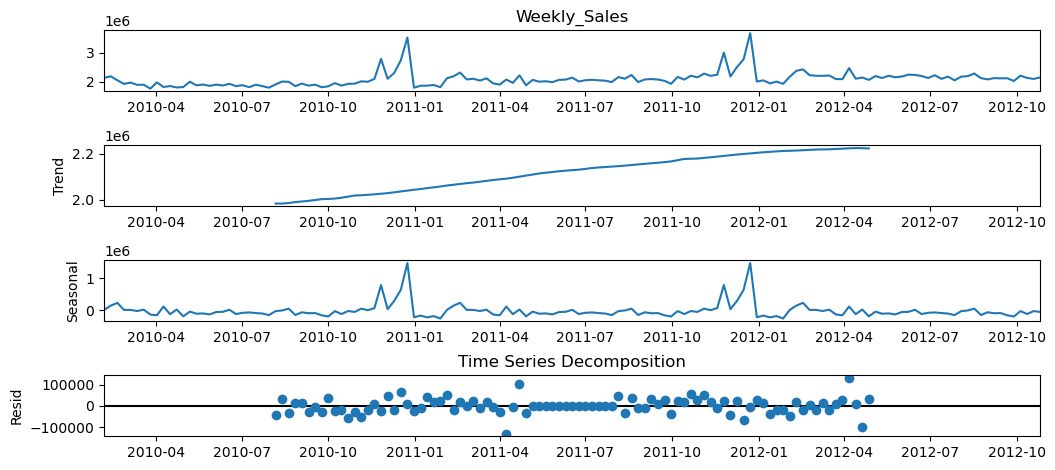

In [376]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df_4["Weekly_Sales"])
fig=decomposition.plot()
fig.set_figwidth(12)
plt.title("Time Series Decomposition")
plt.show()

**Building the model for Stationary data**

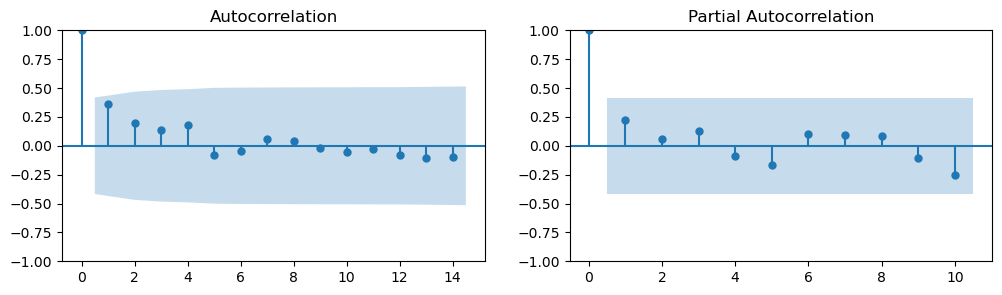

In [377]:
#Plotting the Autcorrelation plot and Partial Autocorrelation plot

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

fig,ax=plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(3)
acf_plot=acf(df_4["Weekly_Sales"])
plot_acf(acf_plot,ax=ax[0])

pacf_plot=pacf(df_4["Weekly_Sales"])
plot_pacf(pacf_plot,ax=ax[1],lags=10)
plt.show()

In [378]:
train=df_4.iloc[:115]["Weekly_Sales"]
test=df_4.iloc[115:]["Weekly_Sales"]

In [379]:
print("Training Data", train.shape)
print("Testing Data",test.shape)

Training Data (115,)
Testing Data (28,)


In [380]:
#Itertools
# How to find the ideal values for p,d,q:

import itertools
from statsmodels.tsa.arima.model import ARIMA
p = range(0,8)
q = range(0,8)
d = range(0,2)

pdq_combination = list(itertools.product(p,d,q))
pdq_combination


print(len(pdq_combination)) #total combinations of p,d,q

from sklearn.metrics import *
rmse = []
order1 = []
for pdq in pdq_combination:
    model = ARIMA(train,order=pdq)
    model_fit=model.fit()
    pred = model_fit.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
    error = np.sqrt(mean_squared_error(test, pred)) #Computing the mean_squarred error
    order1.append(pdq)
    rmse.append(error)
        
results = pd.DataFrame(index=order1, data=rmse, columns=['RMSE']) 
results.sort_values("RMSE",ascending=True) #Least RMSE score are best hyperparamterer for (p,d,q) values

128


,RMSE
"(5, 1, 0)",62349.220054
"(3, 1, 1)",62435.656454
"(3, 1, 2)",62483.983168
"(4, 1, 1)",62541.647249
"(4, 1, 0)",63000.486052
...,...
"(7, 1, 4)",96516.899623
"(6, 0, 4)",96862.500250
"(7, 0, 4)",103260.689154
"(4, 0, 7)",121240.185295


In [381]:
#Running the ARIMA model

model = ARIMA(train,order=(5,1,0),enforce_stationarity=False) #(p,d,q)
model=model.fit()

<Axes: xlabel='Date'>

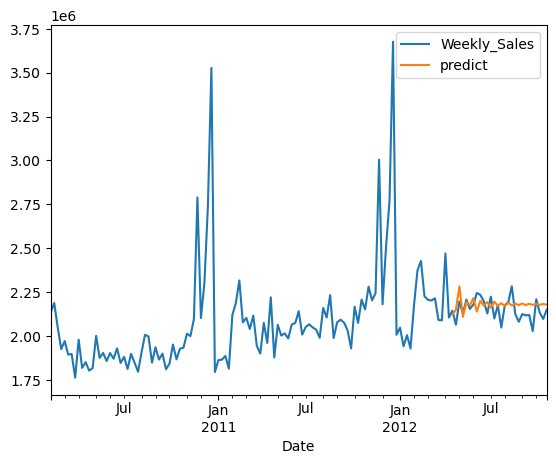

In [382]:
df_4['predict']=model.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
df_4[['Weekly_Sales','predict']].plot()

In [383]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(train,order=(5,1,0),seasonal_order=(5,1,0,12))
model=model.fit()

<Axes: xlabel='Date'>

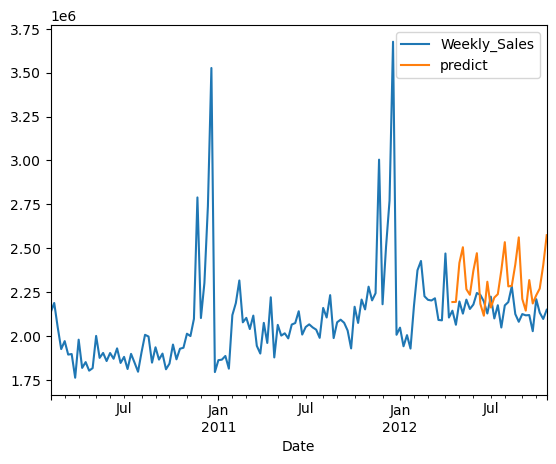

In [384]:
df_4['predict']=model.predict(start=len(train), end=len(train)+len(test)-1,dynamic=True)
df_4[['Weekly_Sales','predict']].plot()

<Axes: xlabel='Date'>

<Figure size 1200x300 with 0 Axes>

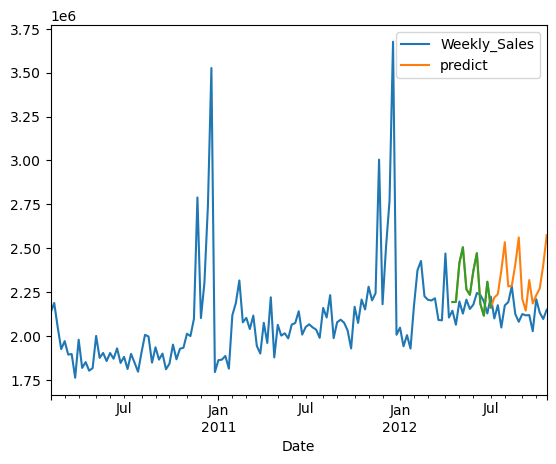

In [385]:
forecast = model.forecast(steps=12) #12 weeks
plt.figure(figsize=(12,3))
df_4.plot()
forecast.plot()

**PREDICTIVE MODELLING FOR WORST PERFORMING STORE :33**

In [386]:
from prophet import Prophet
model=Prophet() #creating an object of the model.

In [387]:
df_33=df[df["Store"]==33]
df_33.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,33,274593.43,0,58.40,2.962,126.442065,10.115,2,2010
2010-02-12,33,294882.83,1,55.47,2.828,126.496258,10.115,2,2010
2010-02-19,33,296850.83,0,62.16,2.915,126.526286,10.115,2,2010
2010-02-26,33,284052.77,0,56.50,2.825,126.552286,10.115,2,2010
2010-03-05,33,291484.89,0,59.17,2.877,126.578286,10.115,3,2010


In [388]:
df_33["ds"]=df_20.index
df_33.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [389]:
df_33.reset_index(drop=True,inplace=True)#Dropping the indexed column
df_33=df_33[["ds","Weekly_Sales"]].rename(columns={"Weekly_Sales":"y"})


In [390]:
df_33.head()

,ds,y
0,2010-02-05,274593.43
1,2010-02-12,294882.83
2,2010-02-19,296850.83
3,2010-02-26,284052.77
4,2010-03-05,291484.89


In [391]:
#Fitting the model
model.fit(df_33)

23:12:42 - cmdstanpy - INFO - Chain [1] start processing
23:12:42 - cmdstanpy - INFO - Chain [1] done processing


In [392]:
# Periods is given in months here(12 weeks = 3months) ,MS stands for Month Start
future_dates=model.make_future_dataframe(periods=12,freq="W-FRI") #The week day it should run is friday

In [393]:
future_dates.tail(20)

,ds
135,2012-09-07
136,2012-09-14
137,2012-09-21
138,2012-09-28
139,2012-10-05
140,2012-10-12
141,2012-10-19
142,2012-10-26
143,2012-11-02
144,2012-11-09


In [394]:
#Maing predictions for the futire dates
forecast=model.predict(future_dates)

In [395]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
150,2012-12-21,265491.665435,241226.761223,289181.392692
151,2012-12-28,268368.277974,244334.180337,291453.908981
152,2013-01-04,268213.002526,244680.316393,293180.414588
153,2013-01-11,267547.190424,244219.055079,291205.895196
154,2013-01-18,268926.806522,243787.891161,291684.552913


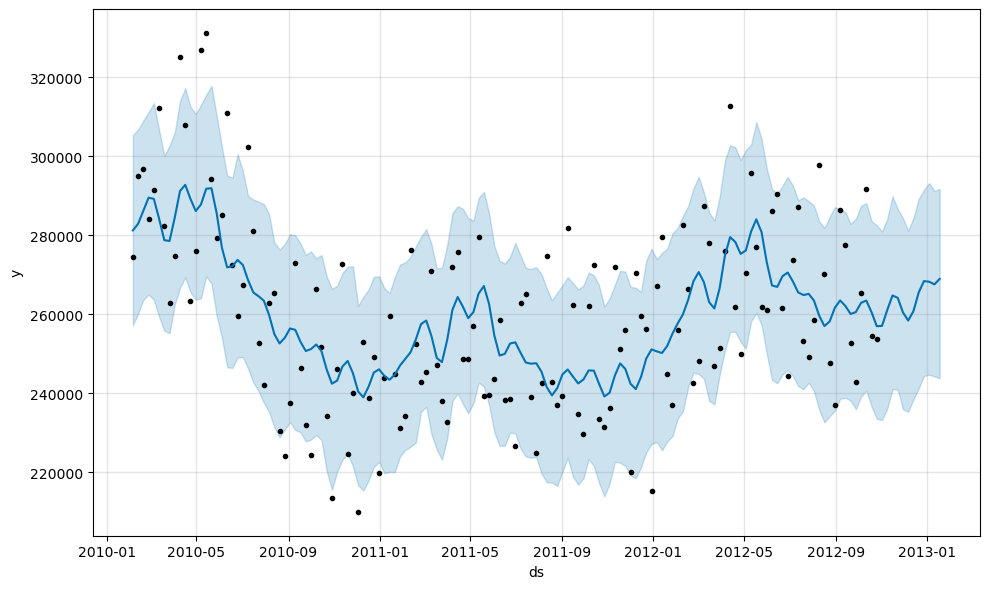

In [396]:
fig1=model.plot(forecast) #Assigning it to fig 1 otherwise 2 graphs are coming

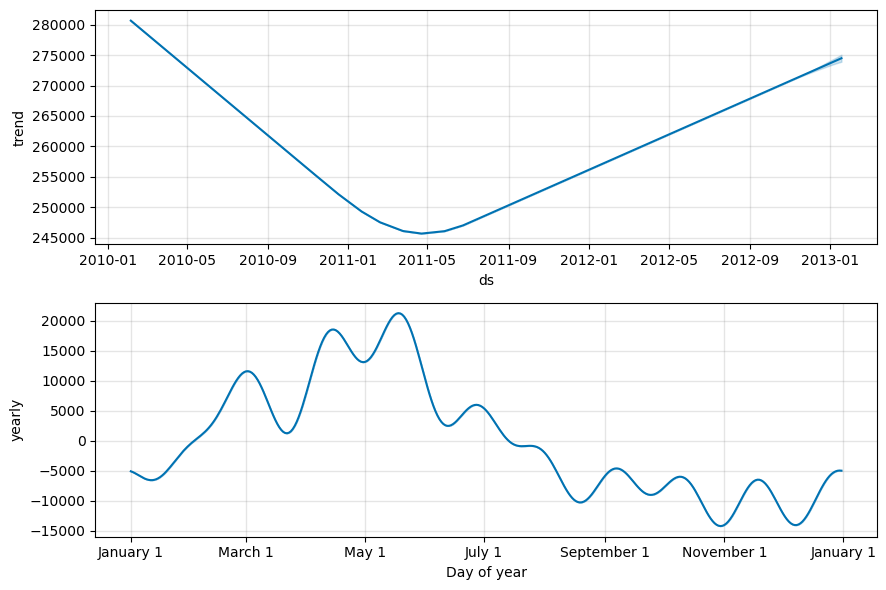

In [397]:
#f you want to see the forecast components, you can use the Prophet.plot_components method. 
#Visualize the components [Trends,yearly]
fig2=model.plot_components(forecast)

In [398]:
from prophet.diagnostics import cross_validation
df_33_cv = cross_validation(model,initial="730 days", period= "45 days", horizon="90 days")

  0%|          | 0/4 [00:00<?, ?it/s]

23:12:46 - cmdstanpy - INFO - Chain [1] start processing
23:12:46 - cmdstanpy - INFO - Chain [1] done processing
23:12:47 - cmdstanpy - INFO - Chain [1] start processing
23:12:47 - cmdstanpy - INFO - Chain [1] done processing
23:12:47 - cmdstanpy - INFO - Chain [1] start processing
23:12:47 - cmdstanpy - INFO - Chain [1] done processing
23:12:48 - cmdstanpy - INFO - Chain [1] start processing
23:12:48 - cmdstanpy - INFO - Chain [1] done processing


In [399]:
from prophet.diagnostics import performance_metrics
df_33_p=performance_metrics(df_33_cv)
df_33_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,8 days,2.351765e+08,15335.464819,12812.575501,0.047056,0.051832,0.047797,0.8
1,9 days,1.995404e+08,14125.878519,11017.168935,0.040845,0.020773,0.041267,0.8
2,12 days,1.135318e+08,10655.129447,8961.488802,0.033569,0.020773,0.033440,1.0
3,13 days,5.903102e+08,24296.299286,18241.789917,0.064568,0.053341,0.067385,0.8
4,15 days,6.373282e+08,25245.360019,20458.236273,0.073499,0.064250,0.075878,0.8
5,16 days,6.966057e+08,26393.288488,21956.349380,0.079771,0.064250,0.081673,0.6
6,19 days,7.032780e+08,26519.389327,22455.506416,0.081345,0.064250,0.083209,0.6
7,20 days,7.384530e+08,27174.491964,23422.020356,0.085940,0.076317,0.088117,0.6
8,22 days,2.611370e+08,16159.734454,14018.321815,0.054457,0.064250,0.053702,0.8
9,23 days,2.201169e+08,14836.337202,12280.738863,0.047059,0.028644,0.046778,0.8


**SARIMAX MODEL**

In [400]:
df_33=df
df_33.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [401]:
df_33=df[df["Store"]==33]
df_33.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,33,274593.43,0,58.40,2.962,126.442065,10.115,2,2010
2010-02-12,33,294882.83,1,55.47,2.828,126.496258,10.115,2,2010
2010-02-19,33,296850.83,0,62.16,2.915,126.526286,10.115,2,2010
2010-02-26,33,284052.77,0,56.50,2.825,126.552286,10.115,2,2010
2010-03-05,33,291484.89,0,59.17,2.877,126.578286,10.115,3,2010


In [402]:
df_33.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [403]:
df_33.head()

,Weekly_Sales
Date,
2010-02-05,274593.43
2010-02-12,294882.83
2010-02-19,296850.83
2010-02-26,284052.77
2010-03-05,291484.89


In [404]:
df_33.isna().sum()

Weekly_Sales    0
dtype: int64

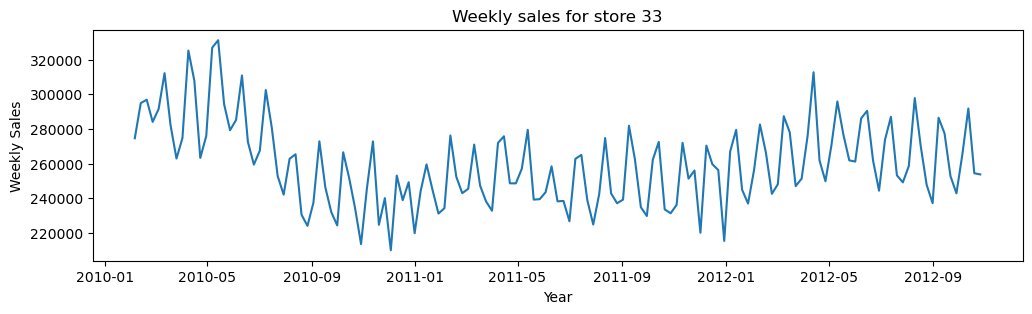

In [405]:
#PLOT THE WEKLY SALES FOR STORE : 20
plt.figure(figsize=(12,3))
plt.plot(df_33["Weekly_Sales"])
plt.xlabel("Year")
plt.ylabel("Weekly Sales")
plt.title(f"Weekly sales for store 33")
plt.show()

**Checking for stationarity in the data**

In [406]:

# Null Hypothesis: Data is not stationary
# Alternate Hypothesis:Data is stationary (This is the claim)
from statsmodels.tsa.stattools import adfuller
result=adfuller(df_33["Weekly_Sales"])
print(f'ADF Statistic:,{result[0]}') #some default value based upon the critial values
print(f'p-value:{result[1]}')

if(result[1]>0.05):
    print("The Data is Not Stationary")
else:
    print("The Data is Stationary")

ADF Statistic:,-4.13787332553231
p-value:0.0008379552269735437
The Data is Stationary


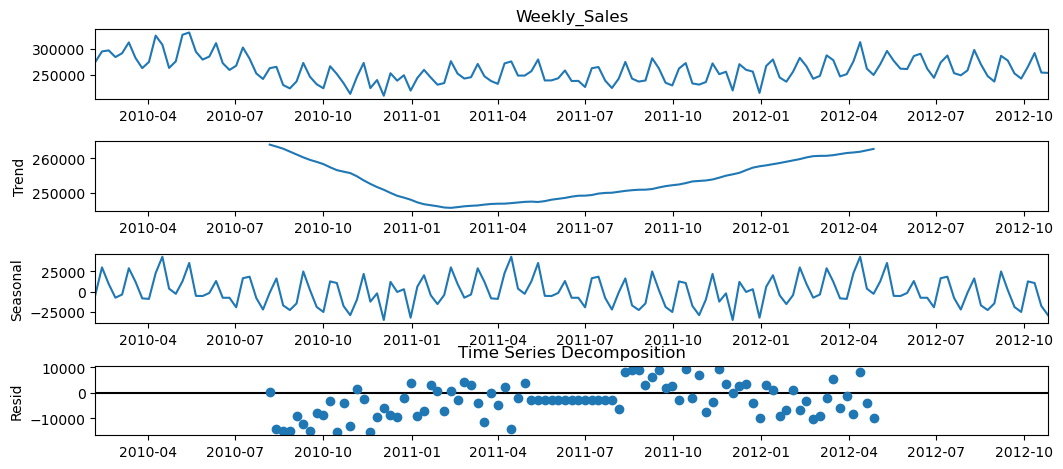

In [407]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df_33["Weekly_Sales"])
fig=decomposition.plot()
fig.set_figwidth(12)
plt.title("Time Series Decomposition")
plt.show()

**Building the model for Stationary data**

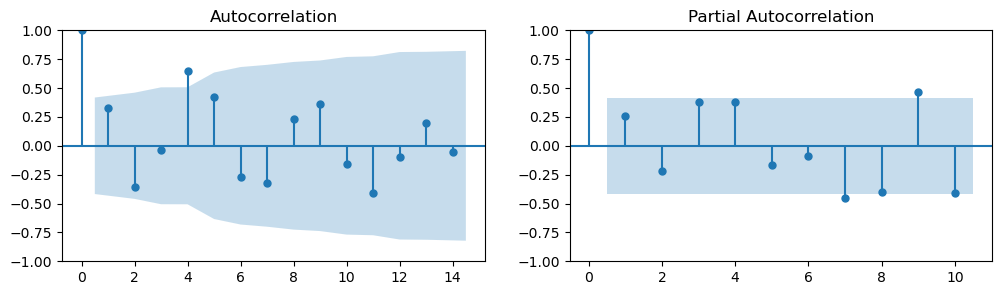

In [408]:
#Plotting the Autcorrelation plot and Partial Autocorrelation plot

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

fig,ax=plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(3)
acf_plot=acf(df_33["Weekly_Sales"])
plot_acf(acf_plot,ax=ax[0])

pacf_plot=pacf(df_33["Weekly_Sales"])
plot_pacf(pacf_plot,ax=ax[1],lags=10)
plt.show()

In [409]:
train=df_33.iloc[:115]["Weekly_Sales"]
test=df_33.iloc[115:]["Weekly_Sales"]

In [410]:
print("Training Data", train.shape)
print("Testing Data",test.shape)

Training Data (115,)
Testing Data (28,)


In [411]:
#Itertools
# How to find the ideal values for p,d,q:

import itertools
from statsmodels.tsa.arima.model import ARIMA
p = range(0,8)
q = range(0,8)
d = range(0,2)

pdq_combination = list(itertools.product(p,d,q))
pdq_combination


print(len(pdq_combination)) #total combinations of p,d,q

from sklearn.metrics import *
rmse = []
order1 = []
for pdq in pdq_combination:
    model = ARIMA(train,order=pdq)
    model_fit=model.fit()
    pred = model_fit.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
    error = np.sqrt(mean_squared_error(test, pred)) #Computing the mean_squarred error
    order1.append(pdq)
    rmse.append(error)
        
results = pd.DataFrame(index=order1, data=rmse, columns=['RMSE']) 
results.sort_values("RMSE",ascending=True) #Least RMSE score are best hyperparamterer for (p,d,q) values

128


,RMSE
"(5, 0, 5)",5388.015747
"(7, 0, 6)",5859.074319
"(5, 0, 4)",6055.654258
"(7, 0, 5)",6240.209111
"(6, 0, 5)",6480.528299
...,...
"(5, 1, 1)",40772.082459
"(5, 1, 0)",42462.950159
"(0, 1, 1)",46775.127451
"(1, 1, 0)",48143.097096


In [412]:
#Running the ARIMA model

model = ARIMA(train,order=(5,0,5)) #(p,d,q)
model=model.fit()

<Axes: xlabel='Date'>

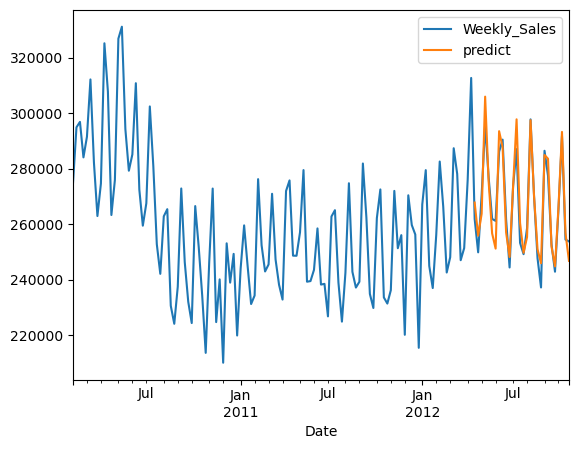

In [413]:
df_33['predict']=model.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
df_33[['Weekly_Sales','predict']].plot()

In [414]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(train,order=(5,0,5),seasonal_order=(5,0,5,12))
model=model.fit()

<Axes: xlabel='Date'>

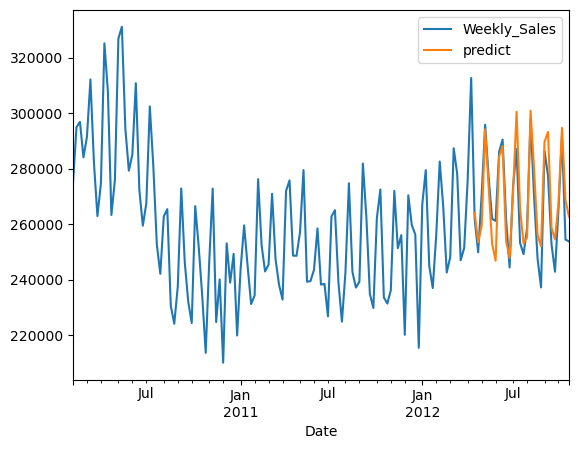

In [415]:
df_33['predict']=model.predict(start=len(train), end=len(train)+len(test)-1,dynamic=True)
df_33[['Weekly_Sales','predict']].plot()

<Axes: xlabel='Date'>

<Figure size 1200x300 with 0 Axes>

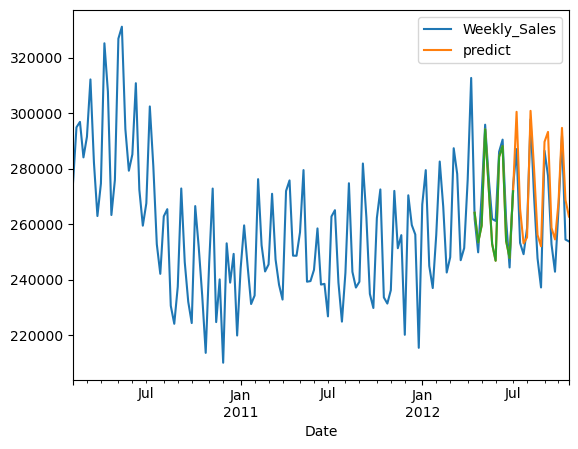

In [416]:
forecast = model.forecast(steps=12) #12 weeks
plt.figure(figsize=(12,3))
df_33.plot()
forecast.plot()

**PREDECTIVE MODELLING FOR THE SECOND WORST PERFORMING STORE :44**

In [417]:
from prophet import Prophet
model=Prophet() #creating an object of the model.

In [418]:
df_44=df[df["Store"]==44]
df_44.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,44,281090.95,0,31.53,2.666,126.442065,8.119,2,2010
2010-02-12,44,286857.13,1,33.16,2.671,126.496258,8.119,2,2010
2010-02-19,44,267956.30,0,35.70,2.654,126.526286,8.119,2,2010
2010-02-26,44,273079.07,0,29.98,2.667,126.552286,8.119,2,2010
2010-03-05,44,284617.27,0,40.65,2.681,126.578286,8.119,3,2010


In [419]:
df_44["ds"]=df_44.index
df_44.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [420]:
df_44.reset_index(drop=True,inplace=True)#Dropping the indexed column

In [421]:
df_44=df_44[["ds","Weekly_Sales"]].rename(columns={"Weekly_Sales":"y"})

In [422]:
df_44.head()

,ds,y
0,2010-02-05,281090.95
1,2010-02-12,286857.13
2,2010-02-19,267956.30
3,2010-02-26,273079.07
4,2010-03-05,284617.27


In [423]:
#Fitting the model
model.fit(df_44)

23:15:07 - cmdstanpy - INFO - Chain [1] start processing


23:15:07 - cmdstanpy - INFO - Chain [1] done processing


In [424]:
# Periods is given in months here(12 weeks = 3months) ,MS stands for Month Start
future_dates=model.make_future_dataframe(periods=12,freq="W-FRI") #The week day it should run is friday

In [425]:
future_dates.tail(20)

,ds
135,2012-09-07
136,2012-09-14
137,2012-09-21
138,2012-09-28
139,2012-10-05
140,2012-10-12
141,2012-10-19
142,2012-10-26
143,2012-11-02
144,2012-11-09


In [426]:
#Maing predictions for the futire dates
forecast=model.predict(future_dates)

In [427]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
150,2012-12-21,362498.095331,346109.633798,378191.297653
151,2012-12-28,358550.901890,341308.246430,373967.240044
152,2013-01-04,347387.871739,330790.181933,364178.186256
153,2013-01-11,339843.725430,323068.701995,356033.363493
154,2013-01-18,342163.549645,325431.468611,358044.672550


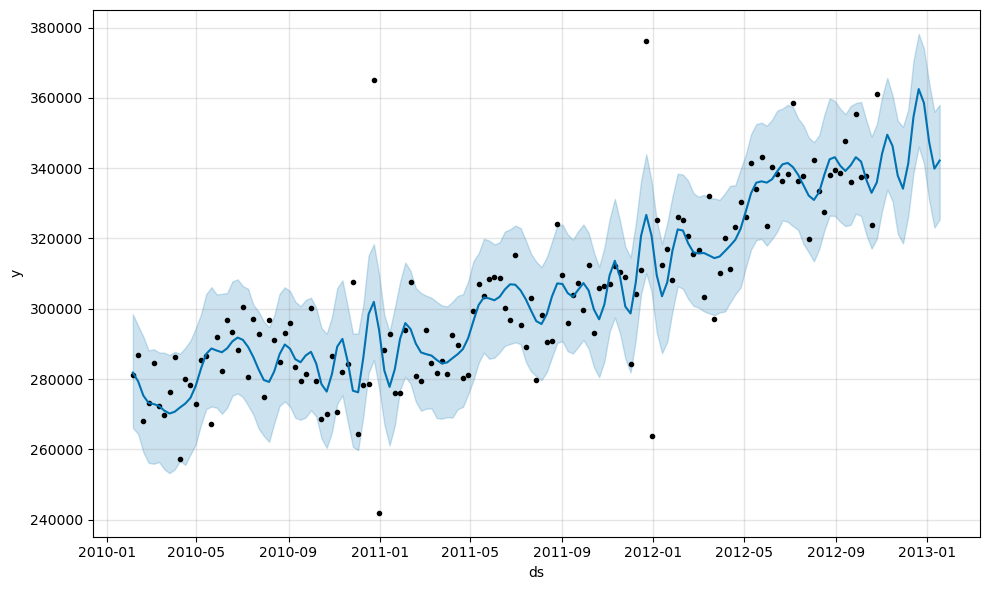

In [428]:
fig1=model.plot(forecast) #Assigning it to fig 1 otherwise 2 graphs are coming

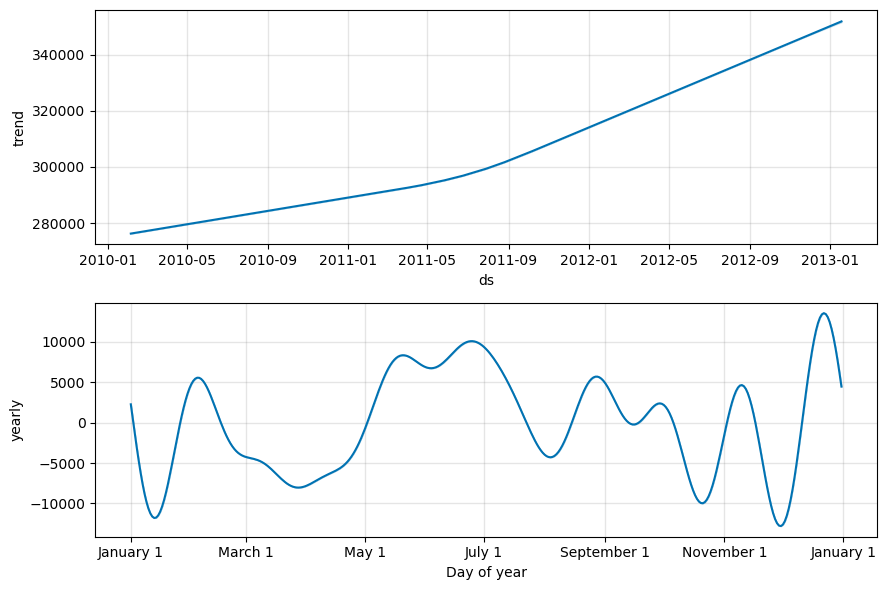

In [429]:
#f you want to see the forecast components, you can use the Prophet.plot_components method. 
#Visualize the components [Trends,yearly]
fig2=model.plot_components(forecast)

In [430]:
from prophet.diagnostics import cross_validation
df_44_cv = cross_validation(model,initial="730 days", period= "45 days", horizon="90 days")

  0%|          | 0/4 [00:00<?, ?it/s]

23:15:12 - cmdstanpy - INFO - Chain [1] start processing
23:15:13 - cmdstanpy - INFO - Chain [1] done processing
23:15:13 - cmdstanpy - INFO - Chain [1] start processing
23:15:14 - cmdstanpy - INFO - Chain [1] done processing
23:15:14 - cmdstanpy - INFO - Chain [1] start processing
23:15:14 - cmdstanpy - INFO - Chain [1] done processing
23:15:15 - cmdstanpy - INFO - Chain [1] start processing
23:15:15 - cmdstanpy - INFO - Chain [1] done processing


In [431]:
from prophet.diagnostics import performance_metrics
df_44_p=performance_metrics(df_44_cv)
df_44_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,8 days,1.851245e+08,13606.046570,10673.875135,0.032775,0.042047,0.033309,0.8
1,9 days,8.178579e+07,9043.549531,6550.342259,0.020336,0.006618,0.020376,1.0
2,12 days,1.176928e+08,10848.629586,9173.433766,0.028019,0.039259,0.028215,1.0
3,13 days,1.191022e+08,10913.396571,9426.084643,0.028746,0.039259,0.028949,1.0
4,15 days,7.066275e+07,8406.113999,6522.079656,0.020330,0.010255,0.020319,1.0
5,16 days,4.021380e+07,6341.435478,4406.894048,0.013050,0.006607,0.013215,1.0
6,19 days,4.186573e+07,6470.373354,4689.081947,0.013903,0.010255,0.014085,1.0
7,20 days,2.746896e+07,5241.083827,4083.584607,0.012389,0.010255,0.012315,1.0
8,22 days,3.724920e+07,6103.212290,4956.364869,0.015203,0.010874,0.015178,1.0
9,23 days,1.548968e+08,12445.755972,9595.876549,0.028052,0.024326,0.028503,0.8


**SARIMAX MODEL**

In [432]:
df_44=df
df_44.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [433]:
df_44=df[df["Store"]==44]
df_44.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,44,281090.95,0,31.53,2.666,126.442065,8.119,2,2010
2010-02-12,44,286857.13,1,33.16,2.671,126.496258,8.119,2,2010
2010-02-19,44,267956.30,0,35.70,2.654,126.526286,8.119,2,2010
2010-02-26,44,273079.07,0,29.98,2.667,126.552286,8.119,2,2010
2010-03-05,44,284617.27,0,40.65,2.681,126.578286,8.119,3,2010


In [434]:
df_44.drop(columns=["Store","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment","Month","Year"],axis=1,inplace=True)

In [435]:
df_44.head()

,Weekly_Sales
Date,
2010-02-05,281090.95
2010-02-12,286857.13
2010-02-19,267956.30
2010-02-26,273079.07
2010-03-05,284617.27


In [436]:
df_44.isna().sum()

Weekly_Sales    0
dtype: int64

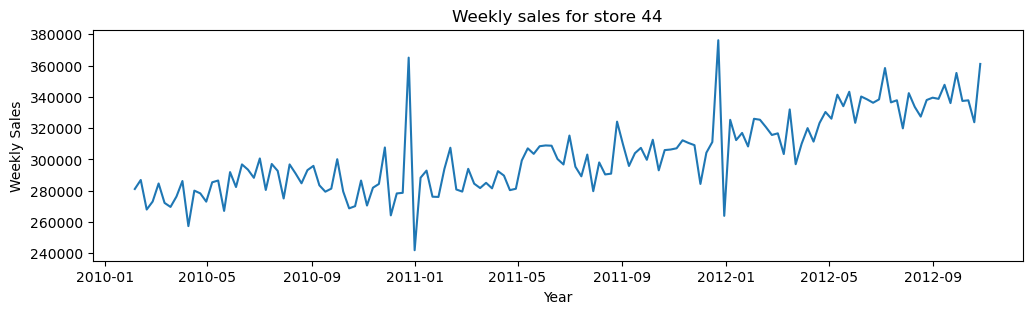

In [437]:
#PLOT THE WEKLY SALES FOR STORE : 20
plt.figure(figsize=(12,3))
plt.plot(df_44["Weekly_Sales"])
plt.xlabel("Year")
plt.ylabel("Weekly Sales")
plt.title(f"Weekly sales for store 44")
plt.show()

**Checking for stationarity in the data**

In [438]:
# Null Hypothesis: Data is not stationary
# Alternate Hypothesis:Data is stationary (This is the claim)
from statsmodels.tsa.stattools import adfuller
result=adfuller(df_44["Weekly_Sales"])
print(f'ADF Statistic:,{result[0]}') #some default value based upon the critial values
print(f'p-value:{result[1]}')

if(result[1]>0.05):
    print("The Data is Not Stationary")
else:
    print("The Data is Stationary")

ADF Statistic:,-0.9837026947465891
p-value:0.7591618635707305
The Data is Not Stationary


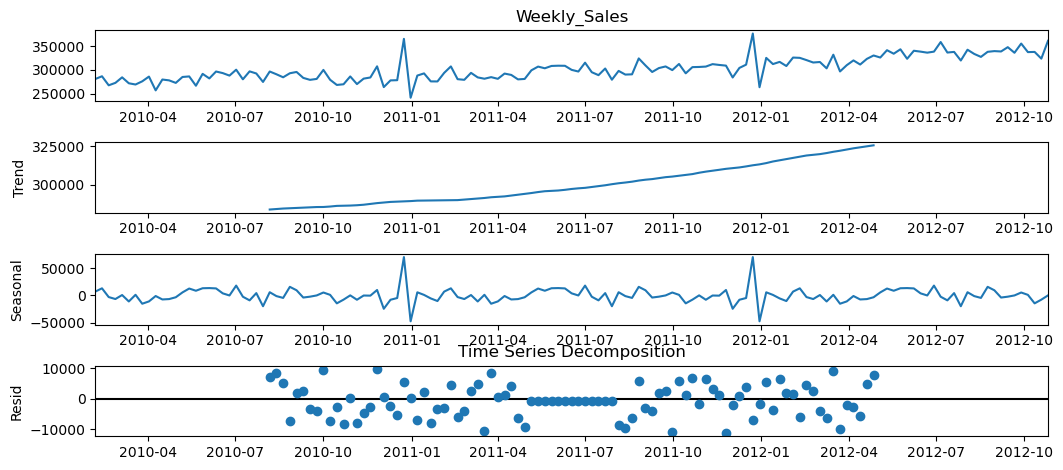

In [439]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df_44["Weekly_Sales"])
fig=decomposition.plot()
fig.set_figwidth(12)
plt.title("Time Series Decomposition")
plt.show()

**ROLLING STATS**

In [440]:
mean_log=df_44.rolling(window=12).mean()
std_log=df_44.rolling(window=12).std()

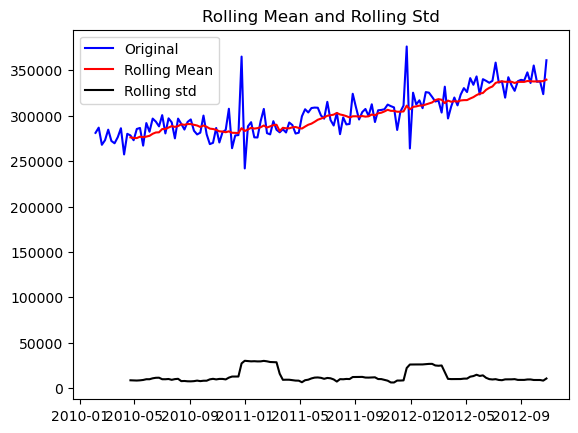

In [441]:
#Lets plot the rolling mean and rolling std
plt.plot(df_44,color='blue',label='Original')
plt.plot(mean_log,color='red',label='Rolling Mean')
plt.plot(std_log,color='black',label='Rolling std')

plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [442]:
#Transformations
first_log=np.log(df_44)

In [443]:
first_log = first_log.dropna()

In [444]:
#Lets plot again
#Rolling stats
mean_log=first_log.rolling(window=12).mean()
std_log=first_log.rolling(window=12).std()

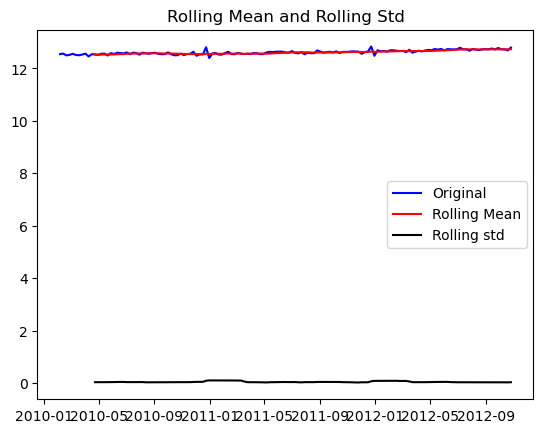

In [445]:
#Lets plot the rolling mean and rolling std
plt.plot(first_log,color='blue',label='Original')
plt.plot(mean_log,color='red',label='Rolling Mean')
plt.plot(std_log,color='black',label='Rolling std')

plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [446]:
new_data = first_log - mean_log
new_data = new_data.dropna()
new_data.head()

,Weekly_Sales
Date,
2010-04-23,0.008227
2010-04-30,-0.008529
2010-05-07,0.036259
2010-05-14,0.034652
2010-05-21,-0.033793


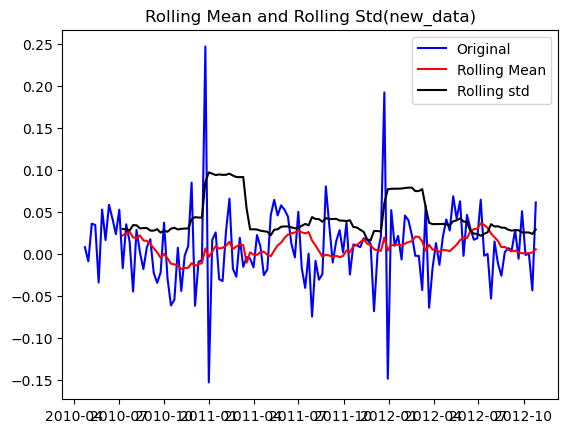

In [447]:
mean_log=new_data.rolling(window=12).mean()
std_log=new_data.rolling(window=12).std()

plt.plot(new_data,color='blue',label='Original')
plt.plot(mean_log,color='red',label='Rolling Mean')
plt.plot(std_log,color='black',label='Rolling std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std(new_data)')
plt.show()

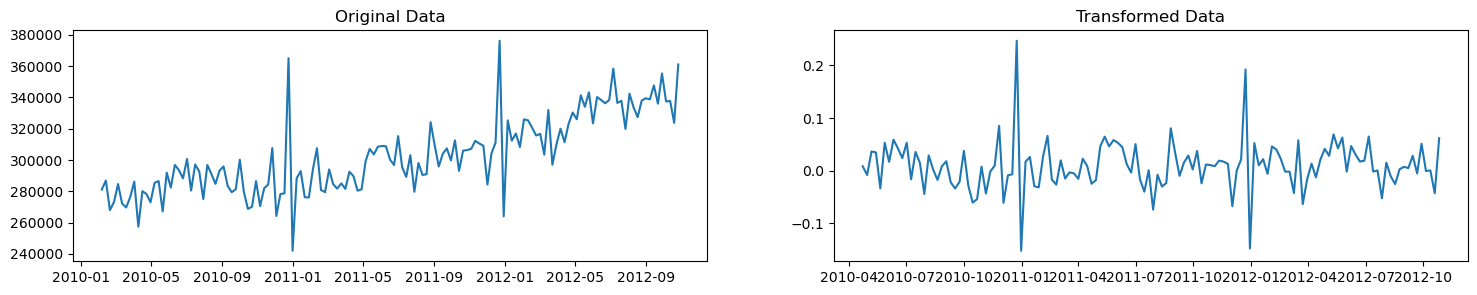

In [448]:
plt.figure(figsize=(18,3))
plt.subplot(1,2,1)
plt.plot(df_44["Weekly_Sales"])
plt.title("Original Data")

plt.subplot(1,2,2)
plt.plot(new_data["Weekly_Sales"])
plt.title("Transformed Data")

plt.show()


In [449]:
from statsmodels.tsa.stattools import adfuller

#ADF Test - if the p-value < 0.05 - Data is stationary
result = adfuller(new_data)

print(f'ADF Statistic,{result[0]}') #some default value based upon the critial values
print(f'p-value={result[1]}')
print(f'n_lags,{result[2]}') #previous no.of observations used for prediction

if(result[1]>0.05):
    print("The Data is not Stationary")
else:
    print("The Data is Stationary")

ADF Statistic,-4.4212656412210185
p-value=0.0002721397555320914
n_lags,3
The Data is Stationary


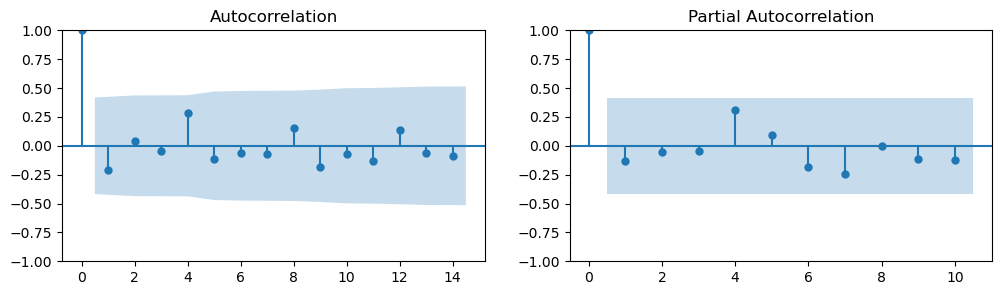

In [450]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(3)
acf_plot=acf(new_data["Weekly_Sales"].dropna()) #Gradual decrease and previuous point to that - 1
plot_acf(acf_plot,ax=ax[0])
pacf_plot=pacf(new_data["Weekly_Sales"].dropna()) #th data point or lag where there is a sudden shut-off - 2
plot_pacf(pacf_plot, lags=10,ax=ax[1])
plt.show()

In [451]:
train=new_data.iloc[:110]["Weekly_Sales"]
test=new_data.iloc[110:]["Weekly_Sales"]

In [452]:
print("Training Set:",train.shape)
print("Testing Set:",test.shape)

Training Set: (110,)
Testing Set: (22,)


In [453]:
#Itertools
# How to find the ideal values for p,d,q:

import itertools
from statsmodels.tsa.arima.model import ARIMA
p = range(0,8)
q = range(0,8)
d = range(0,2)

pdq_combination = list(itertools.product(p,d,q))
pdq_combination


print(len(pdq_combination)) #total combinations of p,d,q

from sklearn.metrics import *
rmse = []
order1 = []
for pdq in pdq_combination:
    model = ARIMA(train,order=pdq)
    model_fit=model.fit()
    pred = model_fit.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
    error = np.sqrt(mean_squared_error(test, pred)) #Computing the mean_squarred error
    order1.append(pdq)
    rmse.append(error)
        
results = pd.DataFrame(index=order1, data=rmse, columns=['RMSE']) 
results.sort_values("RMSE",ascending=True) #Least RMSE score are best hyperparamterer for (p,d,q) values

128


,RMSE
"(3, 1, 4)",0.024621
"(3, 1, 5)",0.024860
"(7, 0, 5)",0.025110
"(6, 1, 6)",0.025129
"(5, 1, 6)",0.025453
...,...
"(4, 1, 0)",0.051444
"(3, 1, 0)",0.052212
"(1, 1, 0)",0.054110
"(2, 1, 0)",0.055167


In [454]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train,order=(3,1,4)) #(p,d,q)
model_fit=model.fit()

<Axes: xlabel='Date'>

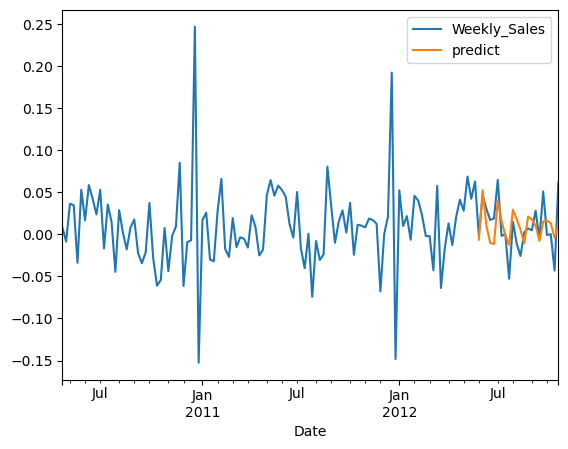

In [455]:
new_data['predict']=model_fit.predict(start=len(train),end=len(train)+len(test)-1, dynamic=True)
new_data[['Weekly_Sales','predict']].plot()

In [456]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model=SARIMAX(train,order=(3,1,4),seasonal_order=(3,1,4,12))
model=model.fit()

<Axes: xlabel='Date'>

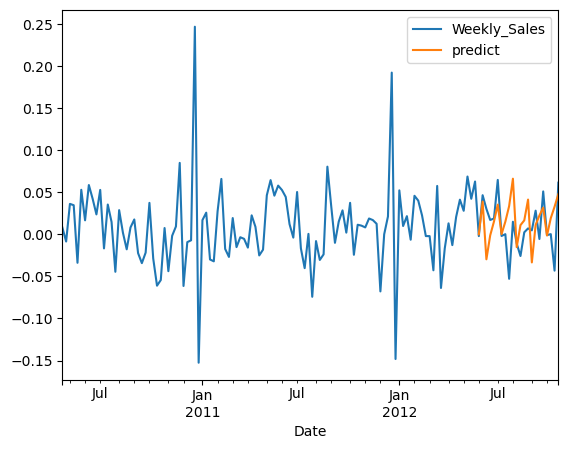

In [457]:
new_data['predict']=model.predict(start=len(train), end=len(train)+len(test)-1,dynamic=True)
new_data[['Weekly_Sales','predict']].plot()

<Axes: xlabel='Date'>

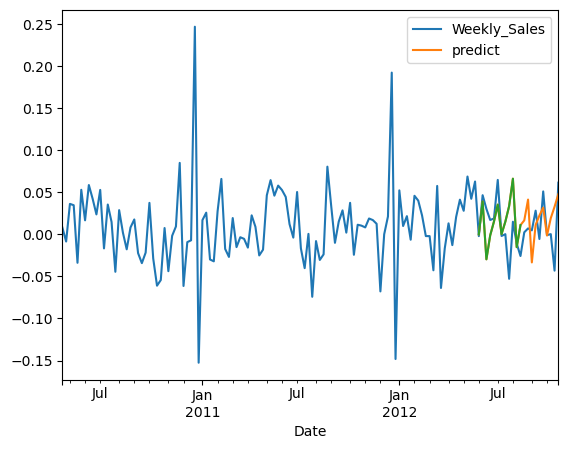

In [458]:
forecast = model.forecast(steps=12) #12 weeks
new_data.plot()
forecast.plot()